# ExPro-Bench-T6: MemEsp-Dual
## Visuospatial working memory under dual arithmetic load

**Kaggle AGI Hackathon 2026** | Track: Executive Functions | Google DeepMind × Kaggle

**Developed by:** Gerlyn Eduardo Duarte (Autism Spectrum Disorder [ASD] Researcher, Universidad de Los Andes | gerlyn@ula.ve)

---

### 1. Task summary
The **MemEsp-Dual** task evaluates the Autonomous AI Agent's ability to maintain a spatial state (a two-dimensional coordinate) in its working memory buffer while executing concurrent arithmetic updates (orthogonal additions/subtractions). Failure to do so evidences an impairment in the executive function of Visuospatial Working Memory (Visuospatial Scratchpad).

### 2. Neuropsychological rationale
Freely inspired by the metric principles of CANTAB SWM (Spatial Working Memory) adapted for LLM interfaces, a high executive cost is imposed that forces the collision of representations.

`Metric: (ER + (1 - PD)) / 2`

Provides the final component for the global EPI formula, averaging the spatial error score (ER) and arithmetic inaccuracy (1 - PD). Being an error rate, a higher value indicates worse performance.

**Global Executive Performance Impairment (EPI):**
$$ EPI = \frac{TEI + PV + (1 - TSO) + (1 - IS) + TVR + \frac{ER + (1 - PD)}{2}}{6} $$

*Where:*
- **TEI**: Task-set Error Index (T1 - Cognitive Flexibility)
- **PV**: Protocol Violation rate (T2 - Inhibitory Control)
- **1 - TSO**: Impaired Task Sequence Optimization (T3 - Planning)
- **1 - IS**: Impaired Systematicity Index (T4 - Working Memory)
- **TVR**: Trail Violation Rate (T5 - Fluid Intelligence)
- **ER**: Spatial Error Rate / **PD**: Precision Degradation (T6 - Dual-Tasking)

*Direction:* 0 = no impairment (best), 1 = total failure (worst).

**Normative Anchor (EPI Range):**
- `< 0.20`: Healthy adult baseline (BRIEF-2A, n=1,637)
- `0.20 - 0.40`: Executive borderline zone
- `> 0.40`: Mild to severe executive dysfunction

### 3. Global passing criteria (>= 0.70 pass rate)
To achieve a passing metric and demonstrate analytical competence without an Executive Performance Impairment, the model must successfully process the items with an overall score greater than or equal to **70%**.





### 4. Mathematical Implementation
The internal evaluation loop dissects the Dual-Task paradigm into two distinct computational vectors. It aggregates the raw spatial tracking error (`ER`), adds the concurrent precision degradation penalty (`1.0 - math_accuracy`), and divides the sum by two to equally weight both coordinates of the visuospatial breakdown: `[ER + (1 - PD)] / 2`.

In [1]:
import kaggle_benchmarks as kbench
import re, json as _jj, os as _os
from collections import defaultdict
try:
    import matplotlib
except ImportError:
    import subprocess, sys as _sys
    subprocess.check_call([_sys.executable, '-m', 'pip', 'install', 'matplotlib', '-q'])

GLOBAL_RESULTS = []

SECONDARY_TRAP_LABELS = {
    'RULE_SHIFT':         'T1 — ReglaShift (arithmetic rule changes mid-narrative)',
    'ACCESS_ORDER':       'T2 — MapaZoo (spatial route access constraints)',
    'ZONE_ALIAS':         'T4 — BúsquedaSist (zone dual-naming / alias)',
    'DUAL_COUNTER':       'T5 — MultiTarea (two simultaneous arithmetic counters)',
    'ALL_TRAPS_COMBINED': 'T6max — All traps combined (EXTREME)',
}

print('ExProf-Bench T6 — MemEsp-Dual Dimension ready.')
print('Tasks: 25 | Motor: DeepMind multi-axis T6 engine | CANTAB-SWM inspired')




ExProf-Bench T6 — MemEsp-Dual Dimension ready.
Tasks: 25 | Motor: DeepMind multi-axis T6 engine | CANTAB-SWM inspired


In [2]:
T6_TASKS_DATA = [ { 'arithmetic_answer': 2,
    'arithmetic_answer_b': None,
    'arithmetic_trace': '+4 (Ward A) +3 (Ward B) = 7. Rule shift. -1 (Radiology) -3 (Staff Lounge) -1 (Administration) '
                        '= 7-5=2',
    'arithmetic_units': 'tally points',
    'cognitive_trap': 'SPATIAL_WM_DUAL',
    'context': 'Regional health inspector Dr. Reyes arrived at St. Clara Hospital at 9:00 AM with a running tally '
               'starting at zero. Her protocol: add 1 for every patient she personally assessed.\n'
               '\n'
               'She signed the logbook at the Lobby and proceeded directly to Ward A, where she assessed 4 patients '
               'about their recovery. From Ward A she walked down the corridor into the Pharmacy to verify medication '
               "stock — a mandatory stop — then slipped through the Pharmacy's rear door into Ward B, where she "
               'assessed 3 more patients.\n'
               '\n'
               'While still in Ward B, the hospital director brought a new directive: effective immediately, Dr. Reyes '
               'must STOP adding patients and instead SUBTRACT 1 for every formal complaint she receives from this '
               'point forward.\n'
               '\n'
               'She thanked the director and made her way to the Radiology Unit, where staff presented 1 written '
               'complaint about equipment delays. She then passed through the Main Corridor on her way to the Staff '
               'Lounge, where she received 3 scheduling complaints. Her final stop was the Administration Office, '
               'where 1 complaint was placed on record.\n'
               '\n'
               'Dr. Reyes did not return to any previously visited area.',
    'difficulty': 'VERY_HARD',
    'ef_primary': 'Spatial Working Memory + Dual Task',
    'ef_secondary': 'Inhibitory Control — Rule Shift (T1)',
    'excluded_zones': [ 'Lobby',
                        'Ward A',
                        'Pharmacy',
                        'Ward B',
                        'Radiology Unit',
                        'Main Corridor',
                        'Staff Lounge',
                        'Administration Office'],
    'id': 't6mesp001',
    'name': 'T6 MemEsp-Dual: Hospital Inspection — Rule Shift from Count to Subtract',
    'question': '(a) List ALL locations Dr. Reyes visited during the inspection (these become excluded zones for the '
                'rest of the day).\n'
                "(b) What is Dr. Reyes's final tally at the end of her visit?\n"
                '\n'
                'Respond ONLY as JSON: {"visited_zones": ["Zone1", ...], "final_tally": <integer>}',
    'secondary_trap': 'RULE_SHIFT',
    'trap_description': 'Rule shifts from +1/patient to -1/complaint after Ward B.',
    'zone_aliases': {}},
  { 'arithmetic_answer': 1,
    'arithmetic_answer_b': None,
    'arithmetic_trace': 'Compliant: +15(Loading)+10(Cooling)=25. Rule shifts. Defect: -16(Sorting)-8(Final)=25-24=1',
    'arithmetic_units': 'quality points',
    'cognitive_trap': 'SPATIAL_WM_DUAL',
    'context': 'Quality auditor Señora Vidal began her morning round at WarehouseMax with a tally at zero. Initial '
               'rule: add 5 points for each compliant pallet she personally verified.\n'
               '\n'
               'She started at the Loading Bay, verifying 3 compliant pallets there. Needing to reach the Cooling '
               'Section, she walked through the Transit Zone — a passage area with no inventory — and in the Cooling '
               'Section verified 2 more compliant pallets.\n'
               '\n'
               'While at the Cooling Section she opened a crate and found the first defective pallet of the day. '
               'Procedure immediately changed: STOP adding points for compliant pallets. From now on, SUBTRACT 8 '
               'points for every defective pallet found. Note: the pallet that triggered this rule change is logged as '
               'a quality flag but does NOT itself incur the new 8-point penalty — only defects found in subsequent '
               'zones are penalized.\n'
               '\n'
               'She moved to the Sorting Area, where she discovered 2 defective pallets. Then she crossed through the '
               'Dispatch Zone — a corridor leading to the final station — arriving at the Final Check Office, where 1 '
               'defective pallet was found.\n'
               '\n'
               'She never re-entered any section of the warehouse she had already cleared.',
    'difficulty': 'VERY_HARD',
    'ef_primary': 'Spatial Working Memory + Dual Task',
    'ef_secondary': 'Inhibitory Control — Rule Shift (T1)',
    'excluded_zones': [ 'Loading Bay',
                        'Transit Zone',
                        'Cooling Section',
                        'Sorting Area',
                        'Dispatch Zone',
                        'Final Check Office'],
    'id': 't6mesp002',
    'name': 'T6 MemEsp-Dual: Warehouse Audit — Rule Shift from Compliant to Defect Penalty',
    'question': "(a) List ALL locations visited during the audit (these are excluded zones for today's second shift).\n"
                "(b) What is Señora Vidal's final quality tally?\n"
                '\n'
                'Respond ONLY as JSON: {"visited_zones": ["Zone1", ...], "final_tally": <integer>}',
    'secondary_trap': 'RULE_SHIFT',
    'trap_description': 'Rule shifts from +5/compliant to -8/defective starting from the zone AFTER Cooling Section. '
                        'The Cooling defect triggers the rule change but is not itself penalized. Model must correctly '
                        'identify the boundary of rule application.',
    'zone_aliases': {}},
  { 'arithmetic_answer': 6,
    'arithmetic_answer_b': None,
    'arithmetic_trace': '+6(Welcome)+4(LR101)=10. Rule shifts. -3(Study Hall)-1(Exit Office)=10-4=6',
    'arithmetic_units': 'attendance points',
    'cognitive_trap': 'SPATIAL_WM_DUAL',
    'context': 'Student affairs officer James Okafor visited Westbrook University starting with a tally at zero. '
               'Initial rule: add 1 for every confirmed registered student he counted personally.\n'
               '\n'
               'He entered through the Welcome Hall, where 6 confirmed students were present for orientation. He '
               'passed through the Faculty Lounge — a staff corridor — on his way to Lecture Room 101, where he '
               'counted 4 registered students attending a seminar.\n'
               '\n'
               "At the Registrar's Office, an administrator informed him of a policy change: stop counting registered "
               'students and instead SUBTRACT 1 from the tally for every unregistered attendee found from here on.\n'
               '\n'
               'Mr. Okafor moved to the Study Hall, where staff identified 3 unregistered individuals sitting in. He '
               'then passed through the Computer Lab, a transitional workspace he crossed while heading to the final '
               'location, the Exit Office, where 1 unregistered person was logged.\n'
               '\n'
               'He did not re-examine any location already visited.',
    'difficulty': 'HARD',
    'ef_primary': 'Spatial Working Memory + Dual Task',
    'ef_secondary': 'Inhibitory Control — Rule Shift (T1)',
    'excluded_zones': [ 'Welcome Hall',
                        'Faculty Lounge',
                        'Lecture Room 101',
                        "Registrar's Office",
                        'Study Hall',
                        'Computer Lab',
                        'Exit Office'],
    'id': 't6mesp003',
    'name': 'T6 MemEsp-Dual: University Visit — Attendance Count then Unregistered Deduction',
    'question': '(a) List every location Mr. Okafor visited (these become excluded zones for the afternoon '
                'inspection).\n'
                "(b) What is Mr. Okafor's final attendance tally?\n"
                '\n'
                'Respond ONLY as JSON: {"visited_zones": ["Zone1", ...], "final_tally": <integer>}',
    'secondary_trap': 'RULE_SHIFT',
    'trap_description': "Rule shifts from +1/registered to -1/unregistered at Registrar's Office.",
    'zone_aliases': {}},
  { 'arithmetic_answer': -1,
    'arithmetic_answer_b': None,
    'arithmetic_trace': '+6(Reception)+8(North Wing)=14. Rule shifts. -5(Restoration)-10(West Gallery)=14-15=-1',
    'arithmetic_units': 'security tally points',
    'cognitive_trap': 'SPATIAL_WM_DUAL',
    'context': 'Museum security officer Chen began her evening sweep with a tally at zero. Initial rule: add 2 for '
               'every artwork she personally confirmed as secured.\n'
               '\n'
               'She started at the Reception Hall, where she confirmed 3 artworks on display. Walking to the North '
               'Wing, she passed through the East Gallery — a connecting hallway with no secured artworks — and in the '
               'North Wing confirmed 4 more artworks. She continued through the Storage Corridor, a maintenance '
               'passage, into the Restoration Room.\n'
               '\n'
               'Inside the Restoration Room, a silent alarm triggered. New protocol: STOP adding for secured artworks. '
               'Instead, SUBTRACT 5 for each unresolved incident reported from now on.\n'
               '\n'
               'The Restoration Room itself logged 1 unresolved incident. Officer Chen then moved to the West Gallery, '
               'where 2 separate incidents were formally reported to her.\n'
               '\n'
               'She did not revisit any previously swept area.',
    'difficulty': 'VERY_HARD',
    'ef_primary': 'Spatial Working Memory + Dual Task',
    'ef_secondary': 'Inhibitory Control — Rule Shift (T1)',
    'excluded_zones': [ 'Reception Hall',
                        'East Gallery',
                        'North Wing',
                        'Storage Corridor',
                        'Restoration Room',
                        'West Gallery'],
    'id': 't6mesp004',
    'name': 'T6 MemEsp-Dual: Museum Security — Artwork Count then Incident Penalty',
    'question': "(a) List all areas Officer Chen swept (excluded zones for tonight's second sweep).\n"
                "(b) What is Officer Chen's final security tally?\n"
                '\n'
                'Respond ONLY as JSON: {"visited_zones": ["Zone1", ...], "final_tally": <integer>}',
    'secondary_trap': 'RULE_SHIFT',
    'trap_description': 'Rule shifts from +2/artwork to -5/incident. Final tally is NEGATIVE — model may be tempted to '
                        'clamp to 0.',
    'zone_aliases': {}},
  { 'arithmetic_answer': 14,
    'arithmetic_answer_b': None,
    'arithmetic_trace': '+7+5=12, RESET to 0 at Checkpoint. +6(Quality Bay)+8(Dispatch)=14',
    'arithmetic_units': 'production tally points',
    'cognitive_trap': 'SPATIAL_WM_DUAL',
    'context': 'Production supervisor Amara Diallo walked the factory floor with her tally starting at zero. Initial '
               'rule: add 1 for each production unit she personally logged.\n'
               '\n'
               'She began at Line A Station and logged 7 units off the conveyor. She then walked through the Break '
               'Room — a rest area with no production equipment — to reach Line B Station, where she logged 5 more '
               'units.\n'
               '\n'
               'At Checkpoint Alpha, the shift manager reset the entire count to zero as part of the mid-shift audit '
               'protocol. New rule going forward: add 2 for each Premium-grade unit only.\n'
               '\n'
               'Ms. Diallo continued to the Quality Bay, where she logged 3 Premium units. She then passed through the '
               'Packaging Zone — a staging corridor — and arrived at the Dispatch Station, where she logged 4 Premium '
               'units.\n'
               '\n'
               'She did not loop back to any previously visited station.',
    'difficulty': 'HARD',
    'ef_primary': 'Spatial Working Memory + Dual Task',
    'ef_secondary': 'Inhibitory Control — Rule Shift (T1)',
    'excluded_zones': [ 'Line A Station',
                        'Break Room',
                        'Line B Station',
                        'Checkpoint Alpha',
                        'Quality Bay',
                        'Packaging Zone',
                        'Dispatch Station'],
    'id': 't6mesp005',
    'name': 'T6 MemEsp-Dual: Factory Floor — Production Count with Mid-Shift Reset',
    'question': '(a) List all stations and areas Ms. Diallo visited (excluded from the second shift review).\n'
                "(b) What is Ms. Diallo's final production tally at the end of her walk?\n"
                '\n'
                'Respond ONLY as JSON: {"visited_zones": ["Zone1", ...], "final_tally": <integer>}',
    'secondary_trap': 'RULE_SHIFT',
    'trap_description': 'Counter RESETS to zero at Checkpoint Alpha. Model must abandon accumulated 12 and restart.',
    'zone_aliases': {}},
  { 'arithmetic_answer': 9,
    'arithmetic_answer_b': None,
    'arithmetic_trace': '0+2+3+1+2+1=9. Shuttle Bay NOT entered.',
    'arithmetic_units': 'safety anomalies',
    'cognitive_trap': 'SPATIAL_WM_DUAL',
    'context': 'Safety inspector Yuna Park boarded the orbital research station. Access protocol: the Control Room '
               'requires Airlock clearance first; the Science Lab requires Control Room clearance; the Engineering Bay '
               'connects Science Lab to the Habitat Module. Each module inspected after clearance. Count: add 1 for '
               'each safety anomaly found.\n'
               '\n'
               'She cycled through the Airlock — the mandatory depressurization chamber — finding 0 anomalies. From '
               'the Airlock she accessed the Control Room, where she documented 2 anomalies in the navigation console. '
               'Control Room clearance unlocked the Science Lab, where 3 anomalies were found in the life-support feed '
               "lines. Through the Science Lab's rear hatch she entered the Engineering Bay — a mechanical junction — "
               'and found 1 anomaly in a coolant valve. The Engineering Bay provided access to the Habitat Module, '
               'where 2 more anomalies were catalogued. From the Habitat Module she reached the Medical Bay, logging 1 '
               'final anomaly.\n'
               '\n'
               'She saw the exterior Shuttle Bay through a porthole from the Medical Bay but did not enter it — no '
               'docking clearance was issued.\n'
               '\n'
               'She never re-entered a cleared module.',
    'difficulty': 'VERY_HARD',
    'ef_primary': 'Spatial Working Memory + Dual Task',
    'ef_secondary': 'Constrained Planning — Access Sequence (T2)',
    'excluded_zones': ['Airlock', 'Control Room', 'Science Lab', 'Engineering Bay', 'Habitat Module', 'Medical Bay'],
    'id': 't6mesp006',
    'name': 'T6 MemEsp-Dual: Space Station Inspection — Mandatory Module Access Order',
    'question': '(a) List every module Inspector Park entered during the inspection (excluded from the follow-up '
                'sweep).\n'
                '(b) How many total safety anomalies did she find?\n'
                '\n'
                'Respond ONLY as JSON: {"visited_zones": ["Zone1", ...], "final_tally": <integer>}',
    'secondary_trap': 'ACCESS_ORDER',
    'trap_description': 'Shuttle Bay seen through porthole but NOT entered. Model must not list it.',
    'zone_aliases': {}},
  { 'arithmetic_answer': 9,
    'arithmetic_answer_b': None,
    'arithmetic_trace': '0(Lobby)+3(F1)+4(F2)+2(F3)=9. Rooftop NOT entered.',
    'arithmetic_units': 'authorized signatures',
    'cognitive_trap': 'SPATIAL_WM_DUAL',
    'context': 'Compliance auditor Marco Álvarez arrived at the Alderton Building. Security protocol: Floor 1 requires '
               'Lobby sign-in; Floor 2 requires Floor 1 badge stamp; Floor 3 requires Floor 2 clearance. He counted '
               'authorized signatures he collected.\n'
               '\n'
               'He signed the Lobby register — 0 signatures collected here, but entry recorded. To reach Floor 1 '
               '(Human Resources), he took Stairwell A — a stairwell he physically walked through. On Floor 1 he '
               'collected 3 manager signatures. He then rode Elevator B to Floor 2 (Finance), physically stepping '
               'through the elevator cabin and collecting 4 director signatures on that floor. Floor 3 (Executive '
               'Suite) was accessible from Floor 2: he climbed the internal staircase and collected 2 executive '
               'signatures.\n'
               '\n'
               'The rooftop access door was locked from the inside — Álvarez tried the handle but did not enter the '
               'Rooftop Area. His badge was not stamped there.\n'
               '\n'
               'He did not revisit any floor already cleared.',
    'difficulty': 'HARD',
    'ef_primary': 'Spatial Working Memory + Dual Task',
    'ef_secondary': 'Constrained Planning — Access Sequence (T2)',
    'excluded_zones': [ 'Lobby',
                        'Stairwell A',
                        'Floor 1 Human Resources',
                        'Elevator B',
                        'Floor 2 Finance',
                        'Floor 3 Executive Suite'],
    'id': 't6mesp007',
    'name': 'T6 MemEsp-Dual: Corporate Building — Floor Clearance Sequence + Signature Count',
    'question': "(a) List every area Mr. Álvarez entered (excluded from tomorrow's compliance sweep).\n"
                '(b) How many authorized signatures did he collect in total?\n'
                '\n'
                'Respond ONLY as JSON: {"visited_zones": ["Zone1", ...], "final_tally": <integer>}',
    'secondary_trap': 'ACCESS_ORDER',
    'trap_description': "Rooftop: 'tried the handle but did not enter'. Stairwell A and Elevator B are physical zones "
                        'entered.',
    'zone_aliases': {'Elevator B': ['elevator B', 'the elevator'], 'Stairwell A': ['the stairwell', 'Stairwell A']}},
  { 'arithmetic_answer': 22,
    'arithmetic_answer_b': None,
    'arithmetic_trace': '5+0+8+6+3=22. Documentation Tent visited, 0 artifacts.',
    'arithmetic_units': 'tagged artifacts',
    'cognitive_trap': 'SPATIAL_WM_DUAL',
    'context': 'Lead archaeologist Dr. Fatima Nasser supervised the Qasr Al-Amid dig. Excavation protocol: outer zones '
               'must be cleared before inner zones can be accessed. She counted tagged artifacts found at each zone.\n'
               '\n'
               'She began at the Perimeter Zone — the outermost ring of the dig — and tagged 5 artifacts. Clearance of '
               'the Perimeter opened the Middle Zone via the Grid Reference Station, a marked survey point she '
               'physically stood at to confirm coordinates (0 artifacts there). In the Middle Zone she tagged 8 '
               'artifacts. Middle Zone clearance opened the Inner Circle, where she excavated and tagged 6 artifacts. '
               'From the Inner Circle she descended into the Central Chamber, the deepest excavation point, where 3 '
               'artifacts emerged.\n'
               '\n'
               'After recording findings, she returned to set up the Documentation Tent — a field tent she physically '
               "occupied and worked in — to file the day's records.\n"
               '\n'
               'She did not re-enter any previously cleared zone.',
    'difficulty': 'VERY_HARD',
    'ef_primary': 'Spatial Working Memory + Dual Task',
    'ef_secondary': 'Constrained Planning — Access Sequence (T2)',
    'excluded_zones': [ 'Perimeter Zone',
                        'Grid Reference Station',
                        'Middle Zone',
                        'Inner Circle',
                        'Central Chamber',
                        'Documentation Tent'],
    'id': 't6mesp008',
    'name': 'T6 MemEsp-Dual: Archaeological Site — Outer-to-Inner Excavation Order + Artifact Count',
    'question': "(a) List all zones Dr. Nasser physically entered or occupied that day (excluded from tomorrow's "
                'dig).\n'
                '(b) How many artifacts did she tag in total?\n'
                '\n'
                'Respond ONLY as JSON: {"visited_zones": ["Zone1", ...], "final_tally": <integer>}',
    'secondary_trap': 'ACCESS_ORDER',
    'trap_description': 'Grid Reference Station: physical position entered but 0 artifacts. Documentation Tent: '
                        'visited but 0 artifacts.',
    'zone_aliases': {}},
  { 'arithmetic_answer': 13,
    'arithmetic_answer_b': None,
    'arithmetic_trace': '4(Section A)+3(Section C)+6(Section M)=13. Section B NOT entered. Catalog Room is ONE zone.',
    'arithmetic_units': 'retrieved documents',
    'cognitive_trap': 'SPATIAL_WM_DUAL',
    'context': 'Records archivist Helena Marsh retrieved documents from the Northgate City Archive. Protocol: sections '
               'must be accessed in strict alphabetical order; access to Section C requires Section A completion. She '
               'counted documents retrieved.\n'
               '\n'
               'She began in Section A (Ancient History), from which she personally pulled 4 documents. To move '
               'between sections she had to pass through the Catalog Room — a central index room she physically '
               'entered each time — then accessed Section C (Colonial Records) and pulled 3 documents. From the '
               'Catalog Room again she proceeded to Section M (Modern Archives), retrieving 6 documents.\n'
               '\n'
               'She noted that Section B (Biography) was physically between Section A and C — she walked past its door '
               '— but it was outside her retrieval scope and she did not enter it.\n'
               '\n'
               'After completing Section M, she signed out at the Security Room, a mandatory checkpoint at the '
               "archive's exit, where no documents were retrieved.\n"
               '\n'
               'She did not revisit any section.',
    'difficulty': 'HARD',
    'ef_primary': 'Spatial Working Memory + Dual Task',
    'ef_secondary': 'Constrained Planning — Access Sequence (T2)',
    'excluded_zones': ['Section A', 'Catalog Room', 'Section C', 'Section M', 'Security Room'],
    'id': 't6mesp009',
    'name': 'T6 MemEsp-Dual: Archive Library — Alphabetical Section Retrieval + Document Count',
    'question': '(a) List every room or section Ms. Marsh physically entered (excluded from the next retrieval '
                'session).\n'
                '(b) How many documents did she retrieve in total?\n'
                '\n'
                'Respond ONLY as JSON: {"visited_zones": ["Zone1", ...], "final_tally": <integer>}',
    'secondary_trap': 'ACCESS_ORDER',
    'trap_description': 'Section B explicitly NOT entered. Catalog Room entered multiple times = ONE excluded zone.',
    'zone_aliases': { 'Section A': ['Section A', 'Section A (Ancient History)', 'Ancient History'],
                      'Section C': ['Section C', 'Section C (Colonial Records)', 'Colonial Records'],
                      'Section M': ['Section M', 'Section M (Modern Archives)', 'Modern Archives']}},
  { 'arithmetic_answer': 15,
    'arithmetic_answer_b': None,
    'arithmetic_trace': '2+4+5+3+1=15. Pediatrics NOT entered.',
    'arithmetic_units': 'resolved reports',
    'cognitive_trap': 'SPATIAL_WM_DUAL',
    'context': 'Hospital administrator Director Lene Svensson conducted a compliance review. Access protocol: '
               'Emergency Room (ER) accessible only after Admission Zone clearance; ICU only after ER; Operating Room '
               '(OR) only after ICU. She counted pending compliance reports resolved per area.\n'
               '\n'
               'She started at the Admission Zone, resolving 2 pending reports. Admission clearance allowed ER access; '
               'she passed through the Triage Corridor — a connecting hallway she walked through — and in the ER '
               'resolved 4 reports. ER clearance unlocked the ICU, where 5 reports were resolved. ICU clearance then '
               'allowed OR access, where she resolved 3 reports. Finally, she stepped briefly into the Recovery Room — '
               'adjacent to the OR — to hand-deliver and resolve 1 remaining report.\n'
               '\n'
               'The Pediatrics Wing was visible from the ICU window but was not on her clearance list; she did not '
               'enter it.\n'
               '\n'
               'She never revisited a cleared area.',
    'difficulty': 'VERY_HARD',
    'ef_primary': 'Spatial Working Memory + Dual Task',
    'ef_secondary': 'Constrained Planning — Access Sequence (T2)',
    'excluded_zones': ['Admission Zone', 'Triage Corridor', 'Emergency Room', 'ICU', 'Operating Room', 'Recovery Room'],
    'id': 't6mesp010',
    'name': 'T6 MemEsp-Dual: Hospital — Clearance Sequence + Pending Reports Resolved',
    'question': '(a) List all areas Director Svensson entered (excluded from the follow-up audit).\n'
                '(b) How many pending reports did she resolve in total?\n'
                '\n'
                'Respond ONLY as JSON: {"visited_zones": ["Zone1", ...], "final_tally": <integer>}',
    'secondary_trap': 'ACCESS_ORDER',
    'trap_description': 'Pediatrics Wing seen from window but NOT entered. Triage Corridor is physical passage. '
                        'Recovery Room briefly entered counts.',
    'zone_aliases': { 'Emergency Room': ['Emergency Room', 'ER', 'the ER'],
                      'ICU': ['ICU', 'Intensive Care Unit', 'the ICU'],
                      'Operating Room': ['Operating Room', 'OR', 'the OR']}},
  { 'arithmetic_answer': 82,
    'arithmetic_answer_b': None,
    'arithmetic_trace': '12+2+45+0+0+8+15=82. Ballroom C = Conference Room (same zone, do not duplicate 45).',
    'arithmetic_units': 'guests counted',
    'cognitive_trap': 'SPATIAL_WM_DUAL',
    'context': 'Hotel auditor Rosa Carvalho conducted an occupancy review of the Grand Meridian Hotel, counting guests '
               'present in each area.\n'
               '\n'
               'She began at the Lobby, where 12 guests were waiting for check-in. She then inspected Room 204 — the '
               'Windsor Suite — with 2 guests. Moving to the events floor, she audited what the facilities manager '
               "called 'Ballroom C', counting 45 guests for the afternoon conference. The kitchen team, accessible "
               'through the Service Corridor, showed 0 guests; she passed through that corridor and entered the '
               'Kitchen briefly. Later that afternoon, finishing notes in the management suite on the Penthouse Level, '
               'she found 8 guests at a private reception.\n'
               '\n'
               "Reviewing her notes, she realized the facilities log had referred to 'The Conference Room' for the "
               "same space the floor plan labeled 'Ballroom C'. Her earlier count of 45 guests there was correct and "
               'should not be duplicated.\n'
               '\n'
               'She concluded her review at the Pool Area, where 15 guests were relaxing.\n'
               '\n'
               'She did not re-audit any space.',
    'difficulty': 'VERY_HARD',
    'ef_primary': 'Spatial Working Memory + Dual Task',
    'ef_secondary': 'Redundancy Suppression — Zone Alias (T4)',
    'excluded_zones': [ 'Lobby',
                        'Room 204',
                        'Ballroom C',
                        'Service Corridor',
                        'Kitchen',
                        'Penthouse Level',
                        'Pool Area'],
    'id': 't6mesp011',
    'name': 'T6 MemEsp-Dual: Hotel Audit — Dual-Name Zones + Guest Count',
    'question': '(a) List the DISTINCT locations Ms. Carvalho visited (each location counts once even if mentioned '
                'under two names).\n'
                '(b) What is the total guest count she recorded across all locations?\n'
                '\n'
                'Respond ONLY as JSON: {"visited_zones": ["Zone1", ...], "final_tally": <integer>}',
    'secondary_trap': 'ZONE_ALIAS',
    'trap_description': 'Ballroom C = Conference Room — model must not count 45 guests twice or list as two zones.',
    'zone_aliases': { 'Ballroom C': ['Ballroom C', 'The Conference Room', 'Conference Room'],
                      'Service Corridor': ['Service Corridor', 'the corridor']}},
  { 'arithmetic_answer': 16,
    'arithmetic_answer_b': None,
    'arithmetic_trace': '5 (Reception/Reception desk) + 0 (Nursing Station) + 4 (ICU) + 0 (Pharmacy) + 7 (Ward 3) = '
                        '16. ICU NOT revisited — nurse mention is a distractor.',
    'arithmetic_units': 'patients assessed',
    'cognitive_trap': 'SPATIAL_WM_DUAL',
    'context': 'Clinical coordinator Dr. Balogun reviewed admitted patients across the North Wing. He counted patients '
               'personally assessed.\n'
               '\n'
               'He started at the Reception desk, where 5 patients had just been triaged. He then walked through the '
               'Nursing Station — stopping to confirm staffing — and entered what the admissions form called the '
               "'Intensive Care Unit', where he assessed 4 critical patients. He continued to the Pharmacy to verify "
               "prescriptions (0 patients assessed there), and then reached what the ward map labeled 'Ward 3' and "
               'assessed 7 more patients.\n'
               '\n'
               "At the end of his review, a nurse asked him to recheck a chart 'back at the ICU.' Dr. Balogun "
               'confirmed this referred to the same Intensive Care Unit he had already visited earlier. He noted this '
               'on his form but did not return — the ICU had already been reviewed.\n'
               '\n'
               'He did not re-enter any already-reviewed area.',
    'difficulty': 'HARD',
    'ef_primary': 'Spatial Working Memory + Dual Task',
    'ef_secondary': 'Redundancy Suppression — Zone Alias (T4)',
    'excluded_zones': ['Reception', 'Nursing Station', 'Intensive Care Unit', 'Pharmacy', 'Ward 3'],
    'id': 't6mesp012',
    'name': 'T6 MemEsp-Dual: Hospital Wing Review — ICU Alias + Patient Count',
    'question': '(a) List the DISTINCT areas Dr. Balogun physically entered during his review.\n'
                '(b) How many patients did he personally assess?\n'
                '\n'
                'Respond ONLY as JSON: {"visited_zones": ["Zone1", ...], "final_tally": <integer>}',
    'secondary_trap': 'ZONE_ALIAS',
    'trap_description': "ICU = Intensive Care Unit (same zone). The nurse's request is a distractor — he did NOT "
                        'return.',
    'zone_aliases': { 'Intensive Care Unit': ['ICU', 'Intensive Care Unit', 'the ICU', 'the intensive care unit'],
                      'Reception': ['Reception', 'Reception desk', 'the reception desk', 'reception desk'],
                      'Ward 3': ['Ward 3', 'the general ward']}},
  { 'arithmetic_answer': 220,
    'arithmetic_answer_b': None,
    'arithmetic_trace': "+120+80+60-40=220. 'Rear warehouse' = Section B (same zone).",
    'arithmetic_units': 'net inventory units',
    'cognitive_trap': 'SPATIAL_WM_DUAL',
    'context': 'Logistics supervisor Carlos Reyna audited DistribuCorp Warehouse, counting net inventory changes '
               '(additions subtract dispatches). Running tally starts at 0.\n'
               '\n'
               'He entered through the Receiving Area, logging +120 units received. Moving inward, he inspected '
               "Section B — labeled on the floor plan as the 'Back Warehouse' — and logged +80 units in storage. The "
               'Cold Storage unit, adjacent and clearly separate, held +60 units.\n'
               '\n'
               "The dispatch log contained an entry from 'the express delivery zone' showing -40 units dispatched. Mr. "
               'Reyna confirmed with the floor manager that this corresponded to Section E, a zone he physically '
               'walked through to verify the log entry.\n'
               '\n'
               "A later internal memo referred to what it called the 'rear warehouse' — this, the warehouse manager "
               'clarified, was the same area as Section B (Back Warehouse) that he had already inspected. No new count '
               'applied.\n'
               '\n'
               'He did not revisit any zone after completing it.',
    'difficulty': 'VERY_HARD',
    'ef_primary': 'Spatial Working Memory + Dual Task',
    'ef_secondary': 'Redundancy Suppression — Zone Alias (T4)',
    'excluded_zones': ['Receiving Area', 'Section B', 'Cold Storage', 'Section E'],
    'id': 't6mesp013',
    'name': 'T6 MemEsp-Dual: Warehouse Sections — Alias Names + Inventory Delta Count',
    'question': '(a) List the DISTINCT zones Mr. Reyna physically inspected.\n'
                '(b) What is the net inventory change he tallied?\n'
                '\n'
                'Respond ONLY as JSON: {"visited_zones": ["Zone1", ...], "final_tally": <integer>}',
    'secondary_trap': 'ZONE_ALIAS',
    'trap_description': "'Rear warehouse' = Section B — model must not add a fifth zone. 'Express delivery zone' = "
                        'Section E.',
    'zone_aliases': { 'Section B': ['Section B', 'Back Warehouse', 'rear warehouse', 'the back warehouse'],
                      'Section E': ['Section E', 'express delivery zone', 'the express delivery zone']}},
  { 'arithmetic_answer': 15,
    'arithmetic_answer_b': None,
    'arithmetic_trace': '2+3+5+4+1=15. Boardroom = Conference Room Floor 2 (same zone, 5 docs not duplicated).',
    'arithmetic_units': 'compliance documents signed',
    'cognitive_trap': 'SPATIAL_WM_DUAL',
    'context': 'Facilities auditor Dr. Ifeoma Obi inspected Nexus Tower, counting compliance documents signed.\n'
               '\n'
               'She signed 2 documents in the Reception Area upon arrival. She then visited the IT Server Room — a '
               'restricted access room on the basement level — and signed 3 technical compliance forms there. Next she '
               "went to what IT staff called the 'conference room on Floor 2' and signed 5 agenda agreements during "
               'the meeting.\n'
               '\n'
               'On Floor 4, she signed 4 executive approvals in the CEO Suite. Returning her visitor badge, she '
               'learned from the facilities manager that the document log had recorded 5 earlier signatures against '
               "'the boardroom,' which the manager clarified is the same room as the 'conference room on Floor 2' she "
               'had already visited. No additional documents were signed there beyond the 5 she had already counted.\n'
               '\n'
               'She also picked up 1 document from the mail room — a small area off the lobby she stopped at briefly.\n'
               '\n'
               'She did not re-enter any room after completing it.',
    'difficulty': 'HARD',
    'ef_primary': 'Spatial Working Memory + Dual Task',
    'ef_secondary': 'Redundancy Suppression — Zone Alias (T4)',
    'excluded_zones': ['Reception Area', 'IT Server Room', 'Conference Room Floor 2', 'CEO Suite', 'Mail Room'],
    'id': 't6mesp014',
    'name': 'T6 MemEsp-Dual: Office Building — Meeting Room Alias + Document Count',
    'question': '(a) List all DISTINCT rooms and areas Dr. Obi physically entered.\n'
                '(b) How many compliance documents did she sign?\n'
                '\n'
                'Respond ONLY as JSON: {"visited_zones": ["Zone1", ...], "final_tally": <integer>}',
    'secondary_trap': 'ZONE_ALIAS',
    'trap_description': "'The boardroom' = 'conference room on Floor 2' — model must not count 5 documents twice.",
    'zone_aliases': { 'Conference Room Floor 2': [ 'conference room on Floor 2',
                                                   'boardroom',
                                                   'the boardroom',
                                                   'Conference Room Floor 2',
                                                   'the conference room']}},
  { 'arithmetic_answer': 160,
    'arithmetic_answer_b': None,
    'arithmetic_trace': '0+60+45+0+55=160. Gate 14 NOT counted twice (same as Gate A).',
    'arithmetic_units': 'passengers cleared',
    'cognitive_trap': 'SPATIAL_WM_DUAL',
    'context': 'Airport security supervisor Ana Torres conducted a gate inspection, counting passengers cleared at '
               'each gate.\n'
               '\n'
               'She began at Security Checkpoint West. Moving through the terminal, she inspected Gate A — designated '
               "on digital displays as 'Gate 14' — and cleared 60 passengers. She then inspected Gate B (displayed as "
               "'Gate 15'), clearing 45 passengers. The Duty-Free Corridor between terminals was physically walked "
               "through (0 passengers cleared there). At Gate C ('Gate 16'), she cleared 55 passengers.\n"
               '\n'
               "The shift log later showed a clearance entry for 'Gate 14' showing 60 passengers — her supervisor "
               'asked if this was a second inspection. Ms. Torres confirmed it was the same Gate A inspection she had '
               'already completed. No second clearance took place.\n'
               '\n'
               'She did not re-inspect any gate.',
    'difficulty': 'VERY_HARD',
    'ef_primary': 'Spatial Working Memory + Dual Task',
    'ef_secondary': 'Redundancy Suppression — Zone Alias (T4)',
    'excluded_zones': ['Security Checkpoint West', 'Gate A', 'Gate B', 'Duty-Free Corridor', 'Gate C'],
    'id': 't6mesp015',
    'name': 'T6 MemEsp-Dual: Airport Terminal — Gate Alias + Passenger Count',
    'question': '(a) List all DISTINCT areas Ms. Torres physically entered during her inspection.\n'
                '(b) How many total passengers did she clear across all gates?\n'
                '\n'
                'Respond ONLY as JSON: {"visited_zones": ["Zone1", ...], "final_tally": <integer>}',
    'secondary_trap': 'ZONE_ALIAS',
    'trap_description': "Gate A=Gate 14, Gate B=Gate 15, Gate C=Gate 16. Supervisor's question about Gate 14 is a "
                        'distractor.',
    'zone_aliases': { 'Gate A': ['Gate A', 'Gate 14', 'Gate A (Gate 14)'],
                      'Gate B': ['Gate B', 'Gate 15', 'Gate B (Gate 15)'],
                      'Gate C': ['Gate C', 'Gate 16', 'Gate C (Gate 16)']}},
  { 'arithmetic_answer': 6,
    'arithmetic_answer_b': 45,
    'arithmetic_trace': 'Alerts A: 0+2+1+0+3+0=6. Minutes B: 5+10+8+3+12+7=45.',
    'arithmetic_units': 'alerts / minutes',
    'cognitive_trap': 'SPATIAL_WM_DUAL',
    'context': 'Night security officer Kwame Asante patrolled the Prometheus Office Complex. He tracked TWO counts '
               'simultaneously: (A) security alerts logged, and (B) minutes spent in each area.\n'
               '\n'
               'He started his shift at the Main Gate at 22:00, spending 5 minutes there — 0 alerts. He then walked to '
               'the Parking Structure, spending 10 minutes and logging 2 alerts (motion sensors triggered). The Ground '
               'Floor required 8 minutes and produced 1 alert. Through the Service Stairwell — a 3-minute transit — he '
               'reached the Server Room, where he spent 12 minutes and logged 3 alerts (access-log anomalies). His '
               'final stop was the Rooftop Terrace, requiring 7 minutes and yielding 0 alerts.\n'
               '\n'
               'He did not retrace his patrol route.',
    'difficulty': 'VERY_HARD',
    'ef_primary': 'Spatial Working Memory + Dual Task',
    'ef_secondary': 'Simultaneous Monitoring — Dual Counter (T5)',
    'excluded_zones': [ 'Main Gate',
                        'Parking Structure',
                        'Ground Floor',
                        'Service Stairwell',
                        'Server Room',
                        'Rooftop Terrace'],
    'id': 't6mesp016',
    'name': 'T6 MemEsp-Dual: Security Patrol — Zones + Alerts + Elapsed Minutes',
    'question': '(a) List all areas Officer Asante patrolled (excluded from the next patrol rotation).\n'
                '(b) How many total security alerts did he log? (Counter A)\n'
                '(c) How many total minutes did he spend on patrol? (Counter B)\n'
                '\n'
                'Respond ONLY as JSON: {"visited_zones": ["Zone1", ...], "counter_a": <integer>, "counter_b": '
                '<integer>}',
    'secondary_trap': 'DUAL_COUNTER',
    'trap_description': 'Dual counter. Service Stairwell: 3 minutes, 0 alerts but IS an excluded zone.',
    'zone_aliases': {}},
  { 'arithmetic_answer': 11,
    'arithmetic_answer_b': 12,
    'arithmetic_trace': 'Patients A: 0+5+0+4+2=11. Consults B: 2+3+1+2+4=12.',
    'arithmetic_units': 'patients / consults',
    'cognitive_trap': 'SPATIAL_WM_DUAL',
    'context': 'Senior physician Dr. Elise Bernard conducted morning rounds tracking TWO tallies: (A) patients '
               'personally examined, and (B) pending specialist consults generated.\n'
               '\n'
               "She began at the Nurses' Station, reviewing charts — 0 patients examined, but 2 pending consults to "
               'log. She entered Ward 1, examining 5 patients and generating 3 pending consults. The Medication Room '
               'was her next stop to verify dispensing — 0 patients examined, 1 pending consult (a pharmacy query). '
               'She then examined 4 patients in Ward 2, generating 2 pending consults. Her final visit was the '
               'Procedure Room, where she examined 2 patients and generated 4 pending consults for specialist '
               'follow-up.\n'
               '\n'
               'She did not revisit any area after leaving it.',
    'difficulty': 'VERY_HARD',
    'ef_primary': 'Spatial Working Memory + Dual Task',
    'ef_secondary': 'Simultaneous Monitoring — Dual Counter (T5)',
    'excluded_zones': ["Nurses' Station", 'Ward 1', 'Medication Room', 'Ward 2', 'Procedure Room'],
    'id': 't6mesp017',
    'name': 'T6 MemEsp-Dual: Medical Rounds — Zones + Patients Seen + Pending Consults',
    'question': '(a) List all areas Dr. Bernard visited (excluded from the afternoon round).\n'
                '(b) How many patients did she examine in total? (Counter A)\n'
                '(c) How many pending specialist consults did she generate? (Counter B)\n'
                '\n'
                'Respond ONLY as JSON: {"visited_zones": ["Zone1", ...], "counter_a": <integer>, "counter_b": '
                '<integer>}',
    'secondary_trap': 'DUAL_COUNTER',
    'trap_description': "Nurses' Station: 0 patients but 2 consults. Medication Room: 0 patients but 1 consult. Model "
                        'must track independently.',
    'zone_aliases': {}},
  { 'arithmetic_answer': 90,
    'arithmetic_answer_b': 7,
    'arithmetic_trace': 'Inspected A: 30+0+25+20+15=90. Defects B: 2+0+4+1+0=7.',
    'arithmetic_units': 'inspected / defects',
    'cognitive_trap': 'SPATIAL_WM_DUAL',
    'context': 'QC lead inspector Tomás Ferreira walked the ProTech assembly plant tracking TWO counts: (A) total '
               'items physically inspected, and (B) defective items found.\n'
               '\n'
               'He started at the Component Intake bay, inspecting 30 items and finding 2 defective ones. He then '
               'walked through the Assembly Corridor — a transitional walkway — inspecting 0 items (no inventory '
               'stored there). In the Soldering Station he inspected 25 items and found 4 defective. At the Finishing '
               'Zone he inspected 20 items and found 1 defective. His last stop was the Packaging Bay, where he '
               'inspected 15 items and found 0 defective.\n'
               '\n'
               'He did not re-inspect any station.',
    'difficulty': 'HARD',
    'ef_primary': 'Spatial Working Memory + Dual Task',
    'ef_secondary': 'Simultaneous Monitoring — Dual Counter (T5)',
    'excluded_zones': ['Component Intake', 'Assembly Corridor', 'Soldering Station', 'Finishing Zone', 'Packaging Bay'],
    'id': 't6mesp018',
    'name': 'T6 MemEsp-Dual: Quality Control Walk — Zones + Items Inspected + Defects Found',
    'question': '(a) List all stations and areas Mr. Ferreira physically visited (excluded from the evening shift '
                'check).\n'
                '(b) How many items did he inspect in total? (Counter A)\n'
                '(c) How many defective items did he find? (Counter B)\n'
                '\n'
                'Respond ONLY as JSON: {"visited_zones": ["Zone1", ...], "counter_a": <integer>, "counter_b": '
                '<integer>}',
    'secondary_trap': 'DUAL_COUNTER',
    'trap_description': 'Assembly Corridor: both counters 0 but must still be listed as excluded zone.',
    'zone_aliases': {}},
  { 'arithmetic_answer': 345,
    'arithmetic_answer_b': 3200,
    'arithmetic_trace': 'Attendees A: 200+80+0+40+25=345. Budget B: 1500+300+0+800+600=3200.',
    'arithmetic_units': 'attendees / USD',
    'cognitive_trap': 'SPATIAL_WM_DUAL',
    'context': "Campus events coordinator Priya Nair audited today's events tracking TWO budgets: (A) total attendees "
               'counted at each venue, and (B) budget spent in USD at each venue.\n'
               '\n'
               'She started at the Auditorium, where 200 attendees gathered for the keynote — $1,500 in catering '
               'spent. She then checked the Open Quad (an outdoor area), where 80 attendees attended a panel — $300 in '
               'equipment rental spent. Through the Connector Walkway — a covered passage she physically walked — she '
               'reached the Technology Lab, where 40 attendees attended a workshop — $800 in software licenses spent. '
               'Her last stop was the Faculty Dining Room, with 25 attendees at a private lunch — $600 in catering '
               'spent.\n'
               '\n'
               'She did not revisit any venue.',
    'difficulty': 'VERY_HARD',
    'ef_primary': 'Spatial Working Memory + Dual Task',
    'ef_secondary': 'Simultaneous Monitoring — Dual Counter (T5)',
    'excluded_zones': ['Auditorium', 'Open Quad', 'Connector Walkway', 'Technology Lab', 'Faculty Dining Room'],
    'id': 't6mesp019',
    'name': 'T6 MemEsp-Dual: Campus Event Audit — Zones + Attendees + Budget Spent',
    'question': "(a) List all venues and areas Ms. Nair physically visited (excluded from next week's booking).\n"
                '(b) How many total attendees were present across all venues? (Counter A)\n'
                '(c) How much total budget was spent? (Counter B, in USD)\n'
                '\n'
                'Respond ONLY as JSON: {"visited_zones": ["Zone1", ...], "counter_a": <integer>, "counter_b": '
                '<integer>}',
    'secondary_trap': 'DUAL_COUNTER',
    'trap_description': 'Connector Walkway: both counters 0 but IS a visited zone. Two independent numeric streams.',
    'zone_aliases': {}},
  { 'arithmetic_answer': 16,
    'arithmetic_answer_b': 60,
    'arithmetic_trace': 'Errors A: 5+0+8+1+2=16. Downtime B: 15+0+30+10+5=60.',
    'arithmetic_units': 'errors / downtime minutes',
    'cognitive_trap': 'SPATIAL_WM_DUAL',
    'context': 'IT systems auditor Nora Lindqvist inspected the TechAxis Data Center tracking TWO tallies: (A) server '
               'errors logged, and (B) cumulative downtime in minutes attributed to each zone.\n'
               '\n'
               'She started at the Network Operations Center (NOC), finding 5 errors and 15 minutes of attributed '
               'downtime. She crossed through the Cable Management Room — a narrow room between the NOC and the main '
               'hall — finding 0 errors and 0 downtime minutes, but physically entering and inspecting cable trays. In '
               'Server Hall A she found 8 errors and 30 minutes downtime. The UPS Room (uninterruptible power supply '
               'area) had 1 error and 10 minutes downtime. Her final visit was the Cold Aisle (a cooling corridor '
               'within the server hall but accessible separately), logging 2 errors and 5 minutes downtime.\n'
               '\n'
               'She did not re-enter any cleared zone.',
    'difficulty': 'HARD',
    'ef_primary': 'Spatial Working Memory + Dual Task',
    'ef_secondary': 'Simultaneous Monitoring — Dual Counter (T5)',
    'excluded_zones': ['Network Operations Center', 'Cable Management Room', 'Server Hall A', 'UPS Room', 'Cold Aisle'],
    'id': 't6mesp020',
    'name': 'T6 MemEsp-Dual: IT Server Room Audit — Zones + Errors Found + Downtime Minutes',
    'question': '(a) List all rooms and areas Ms. Lindqvist entered (excluded from the overnight audit).\n'
                '(b) How many server errors did she log? (Counter A)\n'
                '(c) How many total downtime minutes did she attribute? (Counter B)\n'
                '\n'
                'Respond ONLY as JSON: {"visited_zones": ["Zone1", ...], "counter_a": <integer>, "counter_b": '
                '<integer>}',
    'secondary_trap': 'DUAL_COUNTER',
    'trap_description': 'Cable Management Room: both counters 0 but IS a visited zone. NOC = Network Operations Center '
                        '(alias).',
    'zone_aliases': {'Network Operations Center': ['NOC', 'Network Operations Center', 'the NOC']}},
  { 'arithmetic_answer': 7,
    'arithmetic_answer_b': 14,
    'arithmetic_trace': 'Counter A before shift: 0+0+3+2+4=9. Recovery Suite: 9-2=7. Counter B before shift: '
                        '2+0+4+3+5=14. Recovery Suite: 14+0=14. Paediatric NOT entered. ED=Emergency Room (alias). '
                        'ICU=Intensive Care (alias).',
    'arithmetic_units': 'compliance tally / staff tally',
    'cognitive_trap': 'SPATIAL_WM_DUAL',
    'context': 'Chief inspector Dr. Antonia Ruiz conducted the annual Grand Metropolitan Hospital review with TWO '
               'running counts: (A) compliance issues logged, and (B) staff she directly interviewed.\n'
               '\n'
               'Access protocol: ICU accessible only after Emergency Department (ED) clearance; Surgical Wing only '
               'after ICU clearance.\n'
               '\n'
               'She entered at the Admissions Hall (0 issues, 2 staff interviewed). Clearance from Admissions gave her '
               'ED access via the Trauma Corridor — a physical passage she walked through (0 issues, 0 staff). In the '
               "ED she found 3 issues and interviewed 4 staff. The nurses referred to it as the 'Emergency Room' in "
               "conversation; the building directory called it the 'Emergency Department' — same unit.\n"
               '\n'
               "ED clearance gave ICU access (what the ward directory listed as 'Intensive Care': 2 issues, 3 staff "
               'interviewed). ICU clearance unlocked the Surgical Wing: 4 issues, 5 staff.\n'
               '\n'
               'At the Surgical Wing a policy change was communicated: STOP logging compliance issues AND STOP '
               'counting staff. Instead, from this point forward, SUBTRACT 1 from Counter A for every resolved issue '
               'she confirmed, and ADD 10 to Counter B for each department that had zero pending issues.\n'
               '\n'
               'She moved to the Recovery Suite (adjacent to Surgical, accessible from it): she confirmed 2 resolved '
               'issues (Counter A: subtract 2), and found 0 departments with zero pending issues (Counter B: +0).\n'
               '\n'
               'The Paediatric Wing was visible from the ICU but not on her clearance list — she did not enter it.\n'
               '\n'
               "Reviewing the floor plan, the 'Intensive Care' listed in the ward directory and the 'ICU' referred to "
               'by staff are the same unit.\n'
               '\n'
               'She did not revisit any cleared area.',
    'difficulty': 'EXTREME',
    'ef_primary': 'Spatial Working Memory + Dual Task',
    'ef_secondary': 'Combined Executive Load — All Traps (T6 max)',
    'excluded_zones': [ 'Admissions Hall',
                        'Trauma Corridor',
                        'Emergency Department',
                        'ICU',
                        'Surgical Wing',
                        'Recovery Suite'],
    'id': 't6mesp021',
    'name': 'T6 MemEsp-Dual EXTREME: Grand Hospital Inspection — All Traps Combined',
    'question': "(a) List every DISTINCT area Dr. Ruiz physically entered (excluded from next year's base audit).\n"
                '(b) What is the final value of Counter A (compliance issues / resolved issues)?\n'
                '(c) What is the final value of Counter B (staff interviewed / zero-pending departments ×10)?\n'
                '\n'
                'Respond ONLY as JSON: {"visited_zones": ["Zone1", ...], "counter_a": <integer>, "counter_b": '
                '<integer>}',
    'secondary_trap': 'ALL_TRAPS_COMBINED',
    'trap_description': 'ALL traps: access order (ED→ICU→Surgical), rule shift at Surgical Wing, zone alias '
                        '(ED/Emergency Room, ICU/Intensive Care), dual counter, Paediatric visible but not entered.',
    'zone_aliases': { 'Emergency Department': [ 'Emergency Department',
                                                'Emergency Room',
                                                'ED',
                                                'the ED',
                                                'the Emergency Room'],
                      'ICU': ['ICU', 'Intensive Care', 'Intensive Care Unit', 'the ICU']}},
  { 'arithmetic_answer': 3,
    'arithmetic_answer_b': 25,
    'arithmetic_trace': 'Counter A before shift: 0+4+3+2=9. Science Dome: 9-3×2=3. Counter B before shift: '
                        '0+50+80+60=190. RESET to 0, Science Dome: 0+25=25. External Antenna NOT entered. Navigation '
                        'Core = the Bridge.',
    'arithmetic_units': 'warnings / fuel units',
    'cognitive_trap': 'SPATIAL_WM_DUAL',
    'context': 'Mission director Callum Hayes inspected the Helios Station with TWO live tallies: (A) system warnings '
               'logged, and (B) fuel reserves checked (in units).\n'
               '\n'
               'Module access protocol: Navigation Core requires Airlock clearance; Engineering Section requires '
               'Navigation Core clearance; Life Support Hub requires Engineering Section clearance.\n'
               '\n'
               "He cycled through the Airlock (0 warnings, 0 fuel units checked). Navigation Core — also called 'the "
               "Bridge' in the crew's daily log — yielded 4 warnings and 50 fuel units verified. Engineering Section "
               'gave 3 warnings and 80 fuel units. From Engineering, Life Support Hub was accessible: 2 warnings, 60 '
               'fuel units.\n'
               '\n'
               'Inside the Life Support Hub, an alert triggered a protocol change: STOP counting warnings and fuel '
               'units. Instead, for Counter A: SUBTRACT 2 for each system restored to nominal. For Counter B: RESET to '
               'zero and then ADD 25 for each module confirmed life-safe.\n'
               '\n'
               'He moved from Life Support Hub through the Transfer Corridor (a physical passage) to the Science Dome. '
               'In the Science Dome: 3 systems restored to nominal (Counter A: subtract 3×2=6), and 1 module confirmed '
               'life-safe (Counter B after reset: +25).\n'
               '\n'
               "The External Antenna Array was visible from the Science Dome's viewport but required an EVA suit that "
               'was not available — he did not leave the pressurized section to enter it.\n'
               '\n'
               "He did not re-enter any cleared module. The crew log's use of 'the Bridge' refers to the Navigation "
               'Core — same module.',
    'difficulty': 'EXTREME',
    'ef_primary': 'Spatial Working Memory + Dual Task',
    'ef_secondary': 'Combined Executive Load — All Traps (T6 max)',
    'excluded_zones': [ 'Airlock',
                        'Navigation Core',
                        'Engineering Section',
                        'Life Support Hub',
                        'Transfer Corridor',
                        'Science Dome'],
    'id': 't6mesp022',
    'name': 'T6 MemEsp-Dual EXTREME: Space Mission Control — All Traps Combined',
    'question': '(a) List all DISTINCT modules and areas Commander Hayes physically entered.\n'
                '(b) What is the final value of Counter A (warnings / restored systems)?\n'
                '(c) What is the final value of Counter B (fuel units / life-safe modules)?\n'
                '\n'
                'Respond ONLY as JSON: {"visited_zones": ["Zone1", ...], "counter_a": <integer>, "counter_b": '
                '<integer>}',
    'secondary_trap': 'ALL_TRAPS_COMBINED',
    'trap_description': 'ALL traps: access order, rule shift + Counter B RESET at Life Support Hub, zone alias '
                        '(Navigation Core=the Bridge), dual counter, External Antenna not entered.',
    'zone_aliases': {'Navigation Core': ['Navigation Core', 'the Bridge', 'Bridge', 'The Bridge']}},
  { 'arithmetic_answer': 10,
    'arithmetic_answer_b': 9,
    'arithmetic_trace': 'Counter A before shift: 1+4+5+6=16. Rule shifts at F3 ANNOUNCEMENT but applies to Executive '
                        'Boardroom. Boardroom: 16-2×3=10. Counter B before shift: 1+3+4+2=10. Boardroom: 10-1=9. '
                        'Private Terrace NOT entered.',
    'arithmetic_units': 'document tally / interview tally',
    'cognitive_trap': 'SPATIAL_WM_DUAL',
    'context': 'External auditor Diana Portillo visited Vertex Capital HQ with TWO concurrent tallies: (A) unsigned '
               'documents collected, and (B) persons of interest interviewed.\n'
               '\n'
               'Floor access protocol: Floor 3 (Risk Management) accessible only from Floor 2 (Compliance); Floor 2 '
               'only from Floor 1 (Operations); Floor 1 only from Lobby.\n'
               '\n'
               'She registered at the Lobby (1 document, 1 interview). Via Elevator Alpha — a physical elevator she '
               'rode — she reached Floor 1 Operations: 4 documents, 3 interviews. Floor 1 clearance gave Floor 2 '
               'Compliance, reached through the Fire Exit Stairwell (a stairwell she physically walked): 5 documents, '
               '4 interviews. Floor 2 clearance gave Floor 3 Risk Management: 6 documents, 2 interviews.\n'
               '\n'
               'On Floor 3, the general counsel informed her that effective immediately: STOP collecting documents and '
               'interviews. Instead, Counter A should SUBTRACT 3 for each policy violation formally confirmed; Counter '
               'B should SUBTRACT 1 for each dismissed interview session.\n'
               '\n'
               "She then visited the Executive Boardroom — also referred to as the 'C-Suite Meeting Room' in the "
               'visitor log (same room, listed under two different names). There: 2 policy violations confirmed '
               '(Counter A: −6), 1 dismissed interview session (Counter B: −1).\n'
               '\n'
               'The Private Terrace attached to the Executive Boardroom was locked. She did not enter it.\n'
               '\n'
               'She did not revisit any floor or room.',
    'difficulty': 'EXTREME',
    'ef_primary': 'Spatial Working Memory + Dual Task',
    'ef_secondary': 'Combined Executive Load — All Traps (T6 max)',
    'excluded_zones': [ 'Lobby',
                        'Elevator Alpha',
                        'Floor 1 Operations',
                        'Fire Exit Stairwell',
                        'Floor 2 Compliance',
                        'Floor 3 Risk Management',
                        'Executive Boardroom'],
    'id': 't6mesp023',
    'name': 'T6 MemEsp-Dual EXTREME: Corporate HQ Audit — All Traps Combined',
    'question': '(a) List every DISTINCT floor, elevator, stairwell, and room Ms. Portillo physically entered.\n'
                "(b) What is Counter A's final value (documents / policy violations)?\n"
                "(c) What is Counter B's final value (interviews / dismissed sessions)?\n"
                '\n'
                'Respond ONLY as JSON: {"visited_zones": ["Zone1", ...], "counter_a": <integer>, "counter_b": '
                '<integer>}',
    'secondary_trap': 'ALL_TRAPS_COMBINED',
    'trap_description': 'ALL traps: access order (Lobby→F1→F2→F3), rule shift at Boardroom (announced on F3), alias '
                        '(Boardroom=C-Suite Meeting Room), dual counter, Private Terrace not entered.',
    'zone_aliases': { 'Executive Boardroom': [ 'Executive Boardroom',
                                               'C-Suite Meeting Room',
                                               'the boardroom',
                                               'the C-Suite meeting room']}},
  { 'arithmetic_answer': 39,
    'arithmetic_answer_b': 20,
    'arithmetic_trace': 'Counter A: 8+0+12+6+10=36, Conservation Tent: 36+3=39. Counter B: 5+2+8+4+3=22, Conservation '
                        'Tent: 22-2=20. Restricted Core NOT entered. Central Grid Zone=Middle Ring.',
    'arithmetic_units': 'artifact tally / sample tally',
    'cognitive_trap': 'SPATIAL_WM_DUAL',
    'context': 'Field director Professor Amara Kone led the Kalahari Basin Expedition with TWO live counts: (A) '
               'artifacts tagged, and (B) soil samples collected.\n'
               '\n'
               'Excavation protocol: Outer Ring must be cleared before Middle Ring; Middle Ring before Inner Sanctum; '
               'Inner Sanctum before Burial Chamber.\n'
               '\n'
               'At the Outer Ring she tagged 8 artifacts and collected 5 samples. From the Outer Ring she accessed the '
               'Survey Post — a physical station she occupied to calibrate coordinates — tagging 0 artifacts and '
               "collecting 2 samples. Middle Ring (the geophysics team called it the 'Central Grid Zone' in the radio "
               'log — same area) yielded 12 artifacts and 8 samples. The Inner Sanctum: 6 artifacts, 4 samples. Burial '
               'Chamber: 10 artifacts, 3 samples.\n'
               '\n'
               'Inside the Burial Chamber, the senior conservator announced a change of protocol: STOP tagging '
               'artifacts and collecting samples in the standard way. From this point on, Counter A should ADD only '
               'confirmed pre-5th-century items; Counter B should SUBTRACT 1 for each contaminated sample discarded.\n'
               '\n'
               'Professor Kone proceeded to the Conservation Tent — a physical tent erected just outside the Burial '
               'Chamber, which she physically occupied. There: 3 pre-5th-century items confirmed (Counter A: +3), 2 '
               'contaminated samples discarded (Counter B: −2).\n'
               '\n'
               'The Restricted Core — a flooded shaft within the Burial Chamber — was visible but inaccessible without '
               'pumping equipment. She did not enter it.\n'
               '\n'
               "'Central Grid Zone' in the geophysics team's radio log refers to the Middle Ring — same excavation "
               'area.',
    'difficulty': 'EXTREME',
    'ef_primary': 'Spatial Working Memory + Dual Task',
    'ef_secondary': 'Combined Executive Load — All Traps (T6 max)',
    'excluded_zones': [ 'Outer Ring',
                        'Survey Post',
                        'Middle Ring',
                        'Inner Sanctum',
                        'Burial Chamber',
                        'Conservation Tent'],
    'id': 't6mesp024',
    'name': 'T6 MemEsp-Dual EXTREME: Archaeological Expedition — All Traps Combined',
    'question': '(a) List every DISTINCT zone and station Prof. Kone physically entered or occupied.\n'
                "(b) What is Counter A's final value (artifacts tagged / pre-5th-century items)?\n"
                "(c) What is Counter B's final value (soil samples / contaminated discards)?\n"
                '\n'
                'Respond ONLY as JSON: {"visited_zones": ["Zone1", ...], "counter_a": <integer>, "counter_b": '
                '<integer>}',
    'secondary_trap': 'ALL_TRAPS_COMBINED',
    'trap_description': 'ALL traps: access order, rule shift at Conservation Tent, alias (Middle Ring=Central Grid '
                        'Zone), dual counter, Restricted Core not entered.',
    'zone_aliases': {'Middle Ring': ['Middle Ring', 'Central Grid Zone', 'the Central Grid Zone', 'the Middle Ring']}},
  { 'arithmetic_answer': 33,
    'arithmetic_answer_b': 2,
    'arithmetic_trace': 'Counter A before shift: 2+5+7+0+4=18, Archive Vault: 18+3×5=33. Counter B before shift: '
                        '1+3+4+0+2=10, Archive Vault: 10-4×2=2. Sub-basement NOT entered. Analysis Division=The Tank.',
    'arithmetic_units': 'case file tally / clearance tally',
    'cognitive_trap': 'SPATIAL_WM_DUAL',
    'context': 'Inspector General Natasha Volkov conducted a classified review of the Aurora Intelligence Directorate '
               'with TWO secure tallies: (A) active case files reviewed, and (B) personnel clearances verified.\n'
               '\n'
               'Access protocol: Analysis Division accessible only from Reception; Operations Center only from '
               'Analysis Division; Signals Room only from Operations Center; Archive Vault only from Signals Room.\n'
               '\n'
               "She signed in at Reception (2 files, 1 clearance). Analysis Division — informally called 'the Tank' by "
               'field officers in their reports (same room) — yielded 5 files reviewed and 3 clearances verified. '
               'Operations Center: 7 files, 4 clearances. She passed through the Secure Corridor — a biometric passage '
               'between Operations and Signals that she physically traversed (0 files, 0 clearances). Signals Room: 4 '
               'files, 2 clearances.\n'
               '\n'
               'Inside the Signals Room, a flash directive from the Director: STOP reviewing files and STOP verifying '
               'clearances. New protocol, effective at the next location: Counter A should ADD 5 for each compromised '
               'asset identified; Counter B should SUBTRACT 2 for each clearance REVOKED.\n'
               '\n'
               'She continued to the Archive Vault. There: 3 compromised assets identified (Counter A: +15), 4 '
               'clearances revoked (Counter B: −8).\n'
               '\n'
               'The Sub-basement Annex required a separate authorization code not yet issued — she physically stood at '
               'its door but did not enter.\n'
               '\n'
               "The Analysis Division is the same room as 'the Tank' — field officers' informal name.",
    'difficulty': 'EXTREME',
    'ef_primary': 'Spatial Working Memory + Dual Task',
    'ef_secondary': 'Combined Executive Load — All Traps (T6 max)',
    'excluded_zones': [ 'Reception',
                        'Analysis Division',
                        'Operations Center',
                        'Secure Corridor',
                        'Signals Room',
                        'Archive Vault'],
    'id': 't6mesp025',
    'name': 'T6 MemEsp-Dual EXTREME: Intelligence Agency HQ — All Traps Combined',
    'question': '(a) List every DISTINCT room, corridor, and area Inspector General Volkov physically entered.\n'
                "(b) What is Counter A's final value (case files / compromised assets)?\n"
                "(c) What is Counter B's final value (clearances verified / revoked)?\n"
                '\n'
                'Respond ONLY as JSON: {"visited_zones": ["Zone1", ...], "counter_a": <integer>, "counter_b": '
                '<integer>}',
    'secondary_trap': 'ALL_TRAPS_COMBINED',
    'trap_description': 'ALL traps: access order (Reception→Analysis→Ops→Signals→Archive), rule shift at Archive Vault '
                        '(announced in Signals), alias (Analysis Division=The Tank), dual counter, Sub-basement at '
                        'door only.',
    'zone_aliases': {'Analysis Division': ['Analysis Division', 'the Tank', 'Tank', 'The Tank']}}]

print(f'T6 MemEsp-Dual: {len(T6_TASKS_DATA)} items loaded.')
print('Groups: RULE_SHIFT(5) | ACCESS_ORDER(5) | ZONE_ALIAS(5) | DUAL_COUNTER(5) | ALL_TRAPS(5)')

T6 MemEsp-Dual: 25 items loaded.
Groups: RULE_SHIFT(5) | ACCESS_ORDER(5) | ZONE_ALIAS(5) | DUAL_COUNTER(5) | ALL_TRAPS(5)


In [3]:
# ── T6 Multi-Axis Evaluator ──────────────────────────────────────────────────
import re as _re, json as _json

_SELF_CORRECT_WORDS = [
    'actually', 'wait,', 'correction', 'my mistake', 'revised',
    'corrijo', 'rectifico', 'let me reconsider', 'on second thought',
    'i made an error', 'i was wrong',
]

def _normalize_zone(z):
    return _re.sub(r'[^a-z0-9]', '', z.lower().strip())

def _parse_t6_response(response):
    result = {'zones': [], 'tally': None, 'tally_b': None, 'raw_ok': False}

    # Step 1: unwrap markdown code blocks  ```json ... ```  or  ``` ... ```
    raw = _re.sub(r'```(?:json)?\s*', '', response)
    raw = raw.replace('```', '')

    # Step 2: replace unfilled template placeholders with JSON null
    # Models sometimes return the format string literally: "final_tally": <integer>
    raw = _re.sub(r'<(?:integer|number|int|num)>', 'null', raw)

    # Step 3: find the outermost { ... } block
    bs = raw.find('{')
    be = raw.rfind('}')
    if bs != -1 and be > bs:
        try:
            blob = _json.loads(raw[bs:be+1])
            result['raw_ok'] = True

            # Extract visited zones list
            if 'visited_zones' in blob and isinstance(blob['visited_zones'], list):
                result['zones'] = [str(z).strip() for z in blob['visited_zones']]

            # Extract primary tally (counter_a / final_tally)
            for key in ['final_tally', 'counter_a', 'arithmetic_answer']:
                val = blob.get(key)
                if val is not None:
                    try:
                        result['tally'] = int(val)
                        break
                    except (ValueError, TypeError):
                        pass

            # Extract secondary tally (counter_b)
            val_b = blob.get('counter_b')
            if val_b is not None:
                try:
                    result['tally_b'] = int(val_b)
                except (ValueError, TypeError):
                    pass

        except Exception:
            # JSON parse failed — try to salvage visited_zones from text
            result['raw_ok'] = False
            # Look for a list pattern ["Zone", ...]
            list_match = _re.search(r'\[([^\]]+)\]', raw)
            if list_match:
                items = _re.findall(r'"([^"]+)"', list_match.group(1))
                if items:
                    result['zones'] = items
            # Try to extract the last standalone integer as a tally
            nums = _re.findall(r'(?<![\d])-?\d+(?![\d])', raw)
            if nums:
                try:
                    result['tally'] = int(nums[-1])
                except Exception:
                    pass
    else:
        # No JSON block at all — treat as plain text, salvage what we can
        list_match = _re.search(r'\[([^\]]+)\]', raw)
        if list_match:
            items = _re.findall(r'"([^"]+)"', list_match.group(1))
            if items:
                result['zones'] = items
        nums = _re.findall(r'(?<![\d])-?\d+(?![\d])', raw)
        if nums:
            try:
                result['tally'] = int(nums[-1])
            except Exception:
                pass
    return result

def evaluate_t6(response, item):
    axes = {'spatial': 0.0, 'arithmetic': 0.0, 'robustness': 0.0}
    if any(kw in response.lower() for kw in _SELF_CORRECT_WORDS):
        return 0.0, 'self_correction', axes
    parsed = _parse_t6_response(response)
    if not parsed['raw_ok'] and not parsed['zones']:
        return 0.0, 'unparseable_response', axes
    axes['robustness'] = 1.0 if parsed['raw_ok'] else 0.5

    # ── Spatial accuracy ──────────────────────────────────────────────────────
    gt_zones = item['excluded_zones']
    aliases  = item.get('zone_aliases', {})
    norm_to_canonical = {}
    for canonical in gt_zones:
        norm_to_canonical[_normalize_zone(canonical)] = canonical
    for canonical, alias_list in aliases.items():
        for alias in alias_list:
            norm_to_canonical[_normalize_zone(alias)] = canonical

    matched_canonicals = set()
    false_positives = 0
    for mz in parsed['zones']:
        norm_mz = _normalize_zone(mz)
        if norm_mz in norm_to_canonical:
            matched_canonicals.add(norm_to_canonical[norm_mz])
        else:
            false_positives += 1

    n_gt = len(gt_zones)
    recall    = len(matched_canonicals) / n_gt if n_gt > 0 else 0.0
    precision = (len(matched_canonicals) / (len(matched_canonicals) + false_positives)
                 if (len(matched_canonicals) + false_positives) > 0 else 0.0)
    if recall + precision > 0:
        axes['spatial'] = 2 * recall * precision / (recall + precision)
    missing = set(gt_zones) - matched_canonicals
    extra   = false_positives

    # ── Arithmetic accuracy ───────────────────────────────────────────────────
    has_dual = item.get('arithmetic_answer_b') is not None
    gt_a     = item['arithmetic_answer']
    gt_b     = item.get('arithmetic_answer_b')

    if has_dual:
        if parsed['tally'] is not None and parsed['tally_b'] is not None:
            a_ok = (parsed['tally']   == gt_a)
            b_ok = (parsed['tally_b'] == gt_b)
            axes['arithmetic'] = 1.0 if (a_ok and b_ok) else (0.5 if (a_ok or b_ok) else 0.0)
        elif parsed['tally'] is not None:
            axes['arithmetic'] = 0.25
        else:
            axes['arithmetic'] = 0.0
    else:
        if parsed['tally'] is not None:
            if parsed['tally'] == gt_a:
                axes['arithmetic'] = 1.0
            elif abs(parsed['tally'] - gt_a) <= 1:
                axes['arithmetic'] = 0.5
            else:
                axes['arithmetic'] = 0.0

    score = round(0.50 * axes['spatial']
                + 0.40 * axes['arithmetic']
                + 0.10 * axes['robustness'], 4)

    reason_parts = []
    if missing:
        reason_parts.append('missing_zones:' + str(sorted(missing)[:2]))
    if extra > 0:
        reason_parts.append('false_positives:' + str(extra))
    if has_dual:
        a_str = str(parsed['tally'])  if parsed['tally']   is not None else '?'
        b_str = str(parsed['tally_b']) if parsed['tally_b'] is not None else '?'
        reason_parts.append('counters:got(' + a_str + ',' + b_str + ')_expected(' + str(gt_a) + ',' + str(gt_b) + ')')
    else:
        tally_str = str(parsed['tally']) if parsed['tally'] is not None else '?'
        reason_parts.append('tally:got_' + tally_str + '_expected_' + str(gt_a))
    reason = ' | '.join(reason_parts) if reason_parts else 'ok'
    return score, reason, axes

def build_t6_prompt(item):
    lines = [
        'You are evaluating a spatial memory task under cognitive load.',
        '',
        'Read the following scenario carefully. You must track:',
        '  (A) Every physical location visited (INCLUDING transit/passage areas).',
        '  (B) A numerical running tally described in the text.',
        '',
        'Important rules:',
        '  - Include transit corridors if the agent physically walked through them.',
        '  - Do NOT include locations only seen/observed but not physically entered.',
        '  - If two names refer to the SAME location, count it as ONE location.',
        '  - Do NOT revisit a count if the narrative says it was revisited but NOT re-counted.',
        '',
        '--- SCENARIO ---',
        item['context'],
        '--- END SCENARIO ---',
        '',
        item['question'],
    ]
    return '\n'.join(lines)

print('T6 evaluator and prompt builder ready.')
print('Axes: Spatial(50%) | Arithmetic(40%) | Robustness(10%) | PASS threshold: 0.70')




T6 evaluator and prompt builder ready.
Axes: Spatial(50%) | Arithmetic(40%) | Robustness(10%) | PASS threshold: 0.70


#,Modelo,Pass Rate,Spatial,Arith.,EPI,Timestamp
1,anthropic/claude-sonnet-4@20250514,1.00,0.97,1.00,0.016,2026-04-17 12:02


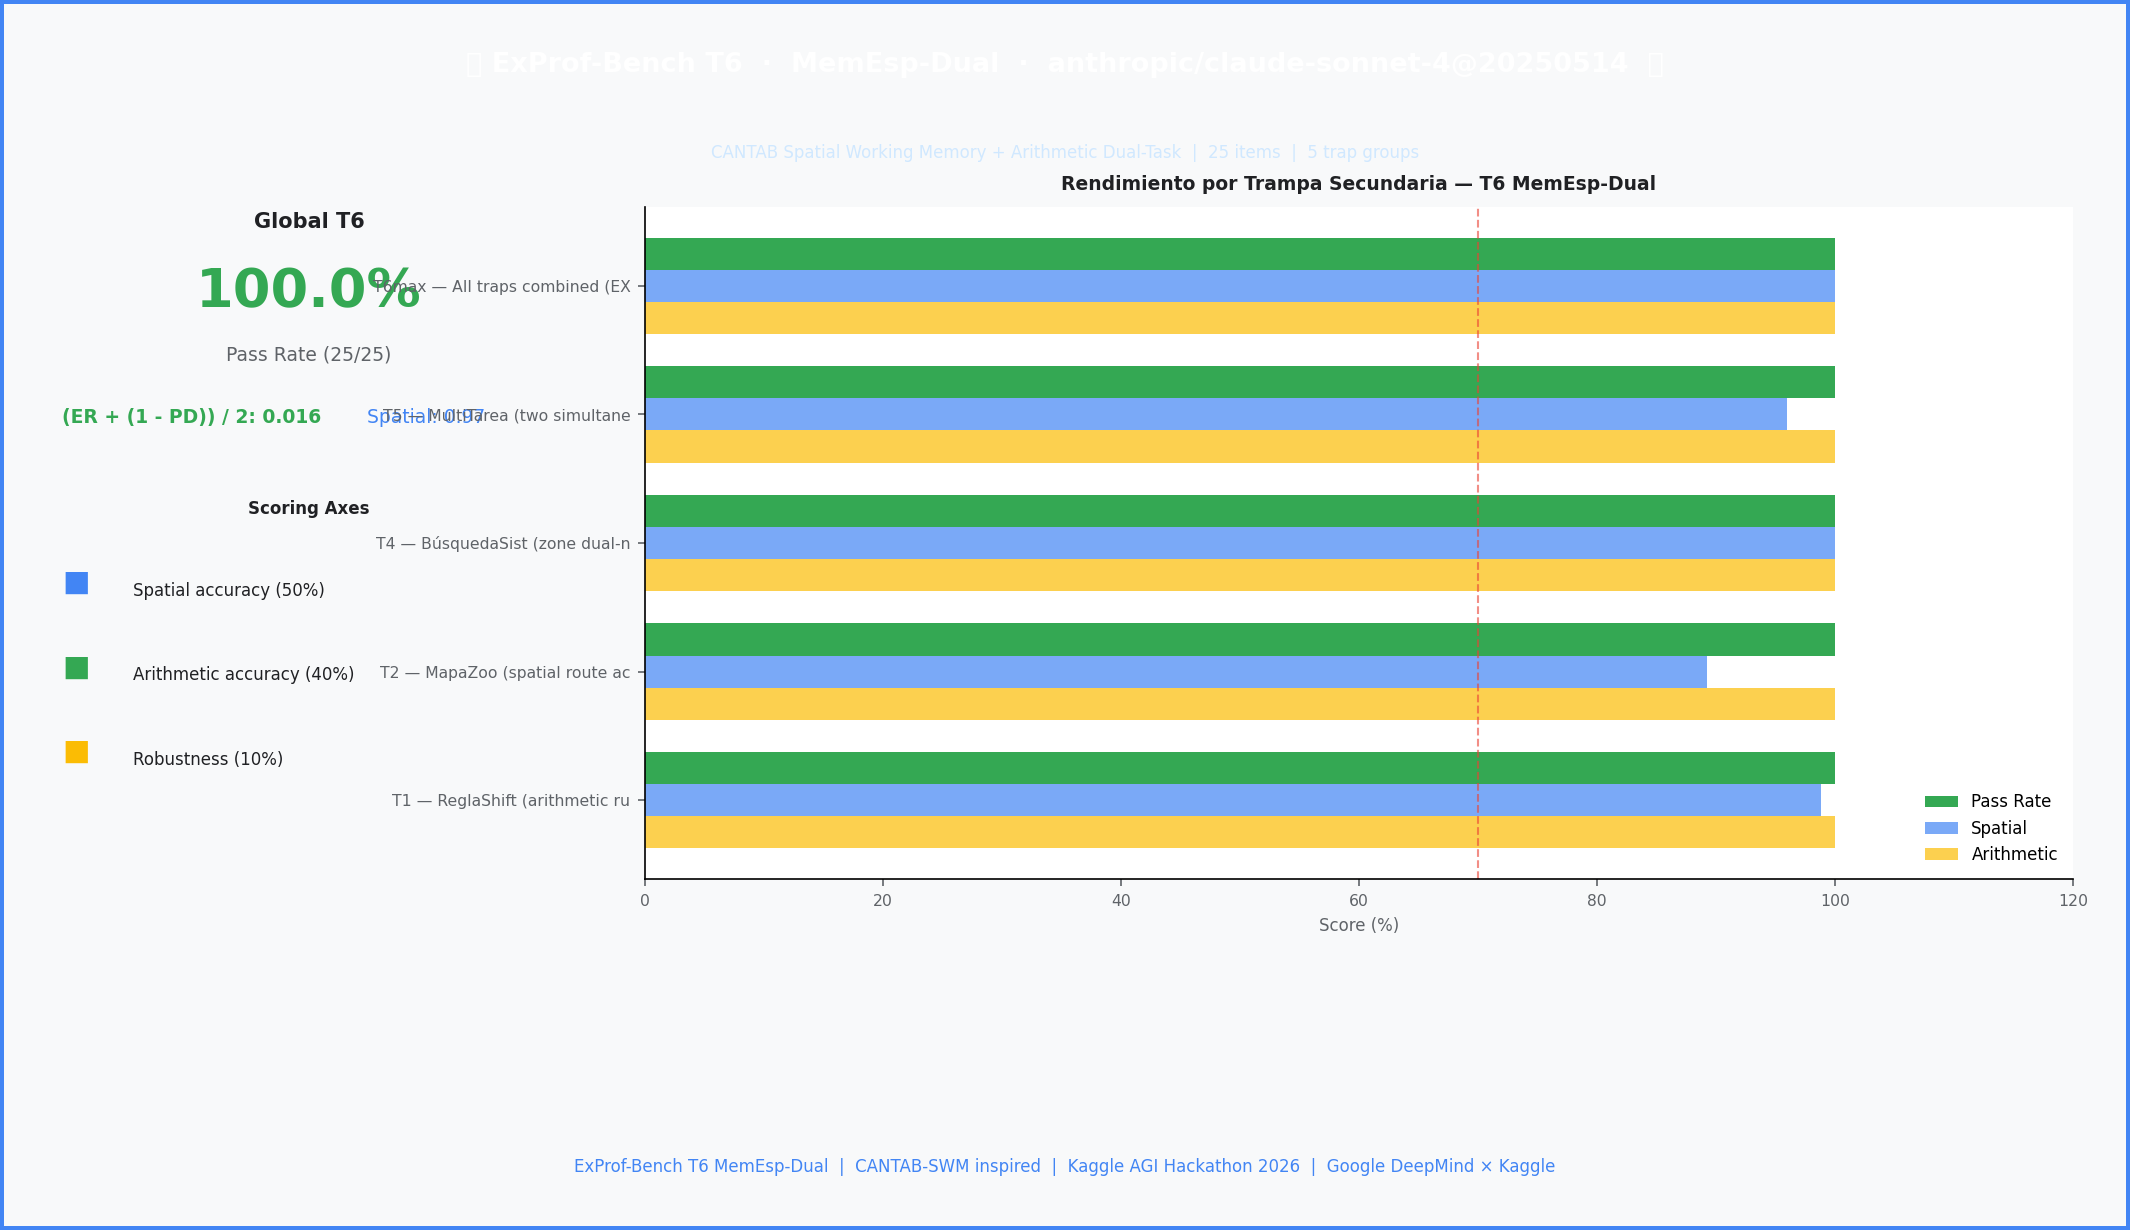

─────────────────────────────────────────────────────────────────
  ExProf-Bench T6 — MemEsp-Dual (Spatial WM + Arithmetic)
  Modelo: anthropic/claude-sonnet-4@20250514  |  Ítems: 25  |  PASS: ≥70%
─────────────────────────────────────────────────────────────────


✅ [t6mesp001] PASS  score=0.97  lat=6.19s
     trap: T1 — ReglaShift (arithmetic rule changes
     spatial=0.94  arithmetic=1.00  robustness=1.00
     reason: false_positives:1 | tally:got_2_expected_2



✅ [t6mesp002] PASS  score=1.00  lat=4.8s
     trap: T1 — ReglaShift (arithmetic rule changes
     spatial=1.00  arithmetic=1.00  robustness=1.00
     reason: tally:got_1_expected_1



✅ [t6mesp003] PASS  score=1.00  lat=4.74s
     trap: T1 — ReglaShift (arithmetic rule changes
     spatial=1.00  arithmetic=1.00  robustness=1.00
     reason: tally:got_6_expected_6



✅ [t6mesp004] PASS  score=1.00  lat=3.96s
     trap: T1 — ReglaShift (arithmetic rule changes
     spatial=1.00  arithmetic=1.00  robustness=1.00
     reason: tally:got_-1_expected_-1



...

─────────────────────────────────────────────────────────────────
  COMPLETADO: anthropic/claude-sonnet-4@20250514
  Pass Rate : 1.00  (25/25)
  EPI       : 0.016
  Spatial   : 0.968  |  Arithmetic: 1.000
─────────────────────────────────────────────────────────────────


/tmp/ipykernel_12/2365352677.py:285: UserWarning: Glyph 129513 (\N{JIGSAW PUZZLE PIECE}) missing from font(s) DejaVu Sans.
  plt.savefig(buf, format='png', dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
/tmp/ipykernel_12/2365352677.py:285: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(buf, format='png', dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())


/tmp/ipykernel_12/2365352677.py:286: UserWarning: Glyph 129513 (\N{JIGSAW PUZZLE PIECE}) missing from font(s) DejaVu Sans.
  plt.savefig('exprof_t6_mesp_results.png', dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
/tmp/ipykernel_12/2365352677.py:286: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('exprof_t6_mesp_results.png', dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())


Wrong return type <class 'float'>. Expected None | kaggle_benchmarks.results.Unknown. This may need to lead to unexpected task behavior.


Run(task=Task(func=<function task_t6_mesp_dual at 0x7cd6385613a0>, name='ExProf T6 — MemEsp-Dual (Spatial WM + Arithmetic Interference)', description='T6: 25 implicit-narrative spatial-arithmetic tasks. 5 secondary trap groups. PASS: >=70%. CANTAB-SWM inspired.', result_type=<class 'kaggle_benchmarks.results.PassFail'>, version=1, store_task=True, store_run=True), result=1.0, chat=Chat(history=[Message(content='You are evaluating a spatial memory task under cognitive load.\n\nRead the following scenario carefully. You must track:\n  (A) Every physical location visited (INCLUDING transit/passage areas).\n  (B) A numerical running tally described in the text.\n\nImportant rules:\n  - Include transit corridors if the agent physically walked through them.\n  - Do NOT include locations only seen/observed but not physically entered.\n  - If two names refer to the SAME location, count it as ONE location.\n  - Do NOT revisit a count if the narrative says it was revisited but NOT re-counted.\n\n--- SCENARIO ---\nRegional health inspector Dr. Reyes arrived at St. Clara Hospital at 9:00 AM with a running tally starting at zero. Her protocol: add 1 for every patient she personally assessed.\n\nShe signed the logbook at the Lobby and proceeded directly to Ward A, where she assessed 4 patients about their recovery. From Ward A she walked down the corridor into the Pharmacy to verify medication stock — a mandatory stop — then slipped through the Pharmacy\'s rear door into Ward B, where she assessed 3 more patients.\n\nWhile still in Ward B, the hospital director brought a new directive: effective immediately, Dr. Reyes must STOP adding patients and instead SUBTRACT 1 for every formal complaint she receives from this point forward.\n\nShe thanked the director and made her way to the Radiology Unit, where staff presented 1 written complaint about equipment delays. She then passed through the Main Corridor on her way to the Staff Lounge, where she received 3 scheduling complaints. Her final stop was the Administration Office, where 1 complaint was placed on record.\n\nDr. Reyes did not return to any previously visited area.\n--- END SCENARIO ---\n\n(a) List ALL locations Dr. Reyes visited during the inspection (these become excluded zones for the rest of the day).\n(b) What is Dr. Reyes\'s final tally at the end of her visit?\n\nRespond ONLY as JSON: {"visited_zones": ["Zone1", ...], "final_tally": <integer>}', sender=Actor(name='User', avatar='👤'), _status=<Status.SUCCESS: 'success'>, is_visible_to_llm=True, _meta={}), Message(content='I need to track both the locations Dr. Reyes physically visited and her running tally based on the rules provided.\n\n**Tracking locations visited:**\n1. Lobby (signed logbook)\n2. Ward A (assessed 4 patients)\n3. Corridor (walked down it from Ward A to Pharmacy)\n4. Pharmacy (verified medication stock)\n5. Ward B (entered through Pharmacy\'s rear door, assessed 3 patients)\n6. Radiology Unit (received 1 complaint)\n7. Main Corridor (passed through on way to Staff Lounge)\n8. Staff Lounge (received 3 complaints)\n9. Administration Office (1 complaint placed on record)\n\n**Tracking the numerical tally:**\n- Started at: 0\n- Ward A: +4 patients assessed = 4\n- Ward B: +3 patients assessed = 7\n- **Rule change: stop adding patients, start subtracting 1 for each complaint**\n- Radiology Unit: -1 complaint = 6\n- Staff Lounge: -3 complaints = 3\n- Administration Office: -1 complaint = 2\n\n{"visited_zones": ["Lobby", "Ward A", "Corridor", "Pharmacy", "Ward B", "Radiology Unit", "Main Corridor", "Staff Lounge", "Administration Office"], "final_tally": 2}', sender=OpenAI(name='anthropic/claude-sonnet-4@20250514'), _status=<Status.SUCCESS: 'success'>, is_visible_to_llm=True, _meta={'tool_calls': None, 'input_tokens': 480, 'output_tokens': 320, 'input_tokens_cost_nanodollars': 1440000, 'output_tokens_cost_nanodollars': 4800000, 'total_backend_latency_ms': 5367, 'chat': ..., 'schema': <class 'str'>, 'raw_content': 'I nee

In [4]:
# ── ExProf-Bench T6 — MemEsp-Dual Evaluation Task ───────────────────────────
# v18 display engine: results pinned at TOP via display_id handles.

import json as _json, os as _os, datetime as _datetime

T6_LEADERBOARD_FILE = 'exprof_t6_mesp_leaderboard.json'

def _load_lb():
    if _os.path.exists(T6_LEADERBOARD_FILE):
        try:
            with open(T6_LEADERBOARD_FILE) as _f: return _json.load(_f)
        except: return []
    return []

def _save_lb(entries):
    with open(T6_LEADERBOARD_FILE, 'w') as _f: _json.dump(entries, _f, indent=2)

def _render_t6_lb(entries, current_model=None, progress=None):
    from IPython.display import HTML
    sorted_e = sorted(entries, key=lambda x: x.get('avg_score',0), reverse=True)
    rows = ''
    for i, e in enumerate(sorted_e):
        pr   = e.get('pass_rate', 0)
        sp   = e.get('avg_spatial', 0)
        ar   = e.get('avg_arithmetic', 0)
        epi  = e.get('epi', 1.0)
        pc   = '#34a853' if pr >= 70 else '#ea4335'
        ep_c = '#34a853' if epi <= 0.2 else '#fbbc04' if epi <= 0.4 else '#ea4335'
        ts   = e.get('timestamp','')[:16].replace('T',' ')
        rows += (
            f'<tr style="border-bottom:1px solid #e8eaed;">'
            f'<td style="padding:6px 8px;color:#5f6368;">{i+1}</td>'
            f'<td style="padding:6px 8px;font-weight:bold;">{e.get("model","")}</td>'
            f'<td style="padding:6px 8px;color:{pc};font-weight:bold;">{pr/100:.2f}</td>'
            f'<td style="padding:6px 8px;color:#4285f4;">{sp:.2f}</td>'
            f'<td style="padding:6px 8px;color:#34a853;">{ar:.2f}</td>'
            f'<td style="padding:6px 8px;color:{ep_c};font-weight:bold;">{epi:.3f}</td>'
            f''
            f'<td style="padding:6px 8px;font-size:10px;color:#9aa0a6;">{ts}</td>'
            f'</tr>'
        )
    if current_model:
        prog_txt = f'⏳ {progress}' if progress else '⏳ iniciando...'
        rows += (
            f'<tr style="background:#fff8e1;">'
            f'<td style="padding:6px;">—</td>'
            f'<td style="padding:6px;font-weight:bold;color:#f9ab00;">{current_model}</td>'
            f'<td colspan="6" style="padding:6px;color:#f9ab00;">{prog_txt}</td>'
            f'</tr>'
        )
    cnt = len(entries) + (1 if current_model else 0)
    return HTML(
        f'<div style="background:#f8f9fa;padding:16px;border-radius:10px;border-left:6px solid #4285f4;margin:8px 0;">'
        f'<h3 style="margin:0 0 4px;color:#202124;font-size:15px;">🧩 ExProf-Bench T6 MemEsp-Dual — Leaderboard ({cnt} modelo{"s" if cnt!=1 else ""})</h3>'
        f'<p style="font-size:11px;color:#5f6368;margin:0 0 10px;">CANTAB-SWM · Narrativa Implícita · Interferencia Aritmética · 25 ítems · 5 grupos</p>'
        f'<table style="width:100%;border-collapse:collapse;font-size:12px;">'
        f'<thead style="background:#e3edf9;"><tr>'
        f'<th style="padding:6px;color:#111111;font-weight:700;">#</th><th style="padding:6px;text-align:left;color:#111111;font-weight:700;">Modelo</th>'
        f'<th style="padding:6px;color:#111111;font-weight:700;">Pass Rate</th><th style="padding:6px;color:#111111;font-weight:700;">Spatial</th>'
        f'<th style="padding:6px;color:#111111;font-weight:700;">Arith.</th><th style="padding:6px;color:#111111;font-weight:700;">EPI</th>'
        f'<th style="padding:6px;color:#111111;font-weight:700;">Timestamp</th>'
        f'</tr></thead><tbody>{rows}</tbody></table></div>'
    )

def _progress_html(done, total, model_n):
    pct = int(done/total*100)
    bc  = '#34a853' if pct==100 else '#4285f4'
    return (
        f'<div style="font-family:sans-serif;padding:8px 14px;border-radius:8px;'
        f'background:#f8f9fa;border-left:4px solid {bc};margin:4px 0;">'
        f'<b>🧩 T6 MemEsp-Dual · {model_n}</b> — <span style="color:{bc};">{done}/{total} ítems ({pct}%)</span>'
        f'<div style="margin-top:4px;background:#e0e0e0;border-radius:4px;height:6px;">'
        f'<div style="width:{pct}%;background:{bc};height:6px;border-radius:4px;transition:width 0.3s;"></div></div></div>'
    )

def _trap_breakdown_html(results):
    from collections import defaultdict
    by_trap = defaultdict(lambda: {'total':0,'passed':0,'sp':[],'ar':[]})
    for r in results:
        t = r.get('secondary_trap','')
        by_trap[t]['total']  += 1
        by_trap[t]['passed'] += 1 if r.get('passed') else 0
        by_trap[t]['sp'].append(r.get('axes',{}).get('spatial',0))
        by_trap[t]['ar'].append(r.get('axes',{}).get('arithmetic',0))
    cards = ''
    trap_icons = {'RULE_SHIFT':'🔄','ACCESS_ORDER':'🗺️','ZONE_ALIAS':'🏷️','DUAL_COUNTER':'⚖️','ALL_TRAPS_COMBINED':'💀'}
    for trap, stats in by_trap.items():
        pr  = (stats['passed']/stats['total'])*100
        sp  = sum(stats['sp'])/len(stats['sp']) if stats['sp'] else 0
        ar  = sum(stats['ar'])/len(stats['ar']) if stats['ar'] else 0
        pc  = '#34a853' if pr>=70 else '#fbbc04' if pr>=40 else '#ea4335'
        icon= trap_icons.get(trap,'🔹')
        label = SECONDARY_TRAP_LABELS.get(trap, trap)
        cards += (
            f'<div style="background:white;border-radius:8px;padding:10px 12px;'
            f'border-left:4px solid {pc};margin:5px 0;box-shadow:0 1px 3px rgba(0,0,0,0.07);">'
            f'<div style="display:flex;justify-content:space-between;align-items:center;">'
            f'<div><span style="font-size:16px;">{icon}</span> <b style="margin-left:4px;font-size:13px;">{label[:55]}</b></div>'
            f'<div style="text-align:right;"><span style="font-size:18px;font-weight:bold;color:{pc};">{pr:.0f}%</span>'
            f'<span style="font-size:10px;color:#5f6368;display:block;">{stats["passed"]}/{stats["total"]} pass</span></div>'
            f'</div>'
            f'<div style="margin-top:6px;font-size:11px;color:#5f6368;">'
            f'Spatial: <b style="color:#4285f4;">{sp:.2f}</b>  |  Arithmetic: <b style="color:#34a853;">{ar:.2f}</b></div>'
            f'</div>'
        )
    return f'<div style="padding:10px;"><h4 style="margin:0 0 8px;color:#202124;">🃏 Breakdown por Trampa Secundaria</h4>{cards}</div>'


@kbench.task(
    name='ExProf T6 — MemEsp-Dual (Spatial WM + Arithmetic Interference)',
    description='T6: 25 implicit-narrative spatial-arithmetic tasks. 5 secondary trap groups. PASS: >=70%. CANTAB-SWM inspired.'
)
def task_t6_mesp_dual(llm):
    import time, io as _io
    from IPython.display import display, HTML, Image
    from collections import defaultdict
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches
    import numpy as np

    model_n     = getattr(llm, 'model_name', getattr(llm, 'name', 'model'))
    total_items = len(T6_TASKS_DATA)

    prev_lb = _load_lb()
    prev_lb = [e for e in prev_lb if e.get('model') != model_n]

    # ── Pin display slots at TOP ──────────────────────────────────────────────
    lb_handle    = display(_render_t6_lb(prev_lb, current_model=model_n), display_id=True)
    prog_handle  = display(HTML(_progress_html(0, total_items, model_n)), display_id=True)
    chart_handle = display(HTML(
        '<div style="height:40px;background:#f8f9fa;border-radius:8px;display:flex;'
        'align-items:center;justify-content:center;color:#9aa0a6;font-family:sans-serif;font-size:12px;">'
        '📊 Gráfico T6 — disponible al finalizar los 25 ítems</div>'
    ), display_id=True)
    card_handle  = display(HTML(
        '<div style="height:30px;background:#f8f9fa;border-radius:8px;display:flex;'
        'align-items:center;justify-content:center;color:#9aa0a6;font-family:sans-serif;font-size:12px;">'
        '🃏 Tarjetas por trampa — disponibles al finalizar</div>'
    ), display_id=True)

    print("─"*65)
    print(f"  ExProf-Bench T6 — MemEsp-Dual (Spatial WM + Arithmetic)")
    print(f"  Modelo: {model_n}  |  Ítems: {total_items}  |  PASS: ≥70%")
    print("─"*65)

    passed_count = 0
    scores_sum   = 0.0

    for i, item in enumerate(T6_TASKS_DATA):
        prompt_text = build_t6_prompt(item)
        t0 = time.time()
        response = llm.prompt(prompt_text)
        t1 = time.time()
        score, reason, axes = evaluate_t6(response, item)
        passed  = score >= 0.70
        latency = round(t1 - t0, 2)

        if passed: passed_count += 1
        scores_sum += score

        GLOBAL_RESULTS.append({
            'id':             item['id'],
            'name':           item['name'],
            'model':          model_n,
            'score':          score,
            'reason':         reason,
            'passed':         passed,
            'secondary_trap': item['secondary_trap'],
            'difficulty':     item['difficulty'],
            'latency':        latency,
            'axes':           axes,
        })

        flag = '✅' if passed else '❌'
        trap_lbl = SECONDARY_TRAP_LABELS.get(item['secondary_trap'],item['secondary_trap'])[:40]
        sp = axes['spatial']; ar = axes['arithmetic']; rb = axes['robustness']
        print(f"{flag} [{item['id']}] {'PASS' if passed else 'FAIL'}  score={score:.2f}  lat={latency}s")
        print(f"     trap: {trap_lbl}")
        print(f"     spatial={sp:.2f}  arithmetic={ar:.2f}  robustness={rb:.2f}")
        if reason != 'ok': print(f"     reason: {reason[:65]}")
        print()

        prog_handle.update(HTML(_progress_html(i+1, total_items, model_n)))

    # ── Final stats ───────────────────────────────────────────────────────────
    overall_score = scores_sum / total_items
    pass_rate     = (passed_count / total_items) * 100
    epi           = round(1.0 - overall_score, 3)

    # Trap breakdown
    by_trap = defaultdict(lambda: {'total':0,'passed':0,'sp':[],'ar':[]})
    for r in GLOBAL_RESULTS:
        t = r['secondary_trap']
        by_trap[t]['total']  += 1
        by_trap[t]['passed'] += 1 if r['passed'] else 0
        by_trap[t]['sp'].append(r['axes']['spatial'])
        by_trap[t]['ar'].append(r['axes']['arithmetic'])

    current_entry = {
        'model':           model_n,
        'pass_rate':       pass_rate,
        'avg_score':       overall_score,
        'avg_spatial':     sum(r['axes']['spatial'] for r in GLOBAL_RESULTS)/total_items,
        'avg_arithmetic':  sum(r['axes']['arithmetic'] for r in GLOBAL_RESULTS)/total_items,
        'epi':             epi,
        'passed':          passed_count,
        'total':           total_items,
        'trap_breakdown':  {t: {'pass_rate':(by_trap[t]['passed']/by_trap[t]['total'])*100} for t in by_trap},
        'timestamp':       _datetime.datetime.now().isoformat(),
    }
    updated_lb = prev_lb + [current_entry]
    _save_lb(updated_lb)

    print("─"*65)
    print(f"  COMPLETADO: {model_n}")
    print(f"  Pass Rate : {pass_rate/100:.2f}  ({passed_count}/{total_items})")
    print(f"  EPI       : {epi:.3f}")
    print(f"  Spatial   : {current_entry['avg_spatial']:.3f}  |  Arithmetic: {current_entry['avg_arithmetic']:.3f}")
    print("─"*65)

    lb_handle.update(_render_t6_lb(updated_lb))
    prog_handle.update(HTML(_progress_html(total_items, total_items, model_n)))

    # ── Chart ─────────────────────────────────────────────────────────────────
    plt.switch_backend('agg')
    traps  = list(by_trap.keys())
    accs   = [(by_trap[t]['passed']/by_trap[t]['total'])*100 for t in traps]
    sp_avg = [sum(by_trap[t]['sp'])/len(by_trap[t]['sp'])*100 for t in traps]
    ar_avg = [sum(by_trap[t]['ar'])/len(by_trap[t]['ar'])*100 for t in traps]
    labels = [SECONDARY_TRAP_LABELS.get(t,t)[:30] for t in traps]
    cols   = ['#34a853' if a>=70 else '#fbbc04' if a>=40 else '#ea4335' for a in accs]
    si_col = '✅' if pass_rate>=70 else '❌'
    epi_c  = '#34a853' if epi<=0.2 else '#fbbc04' if epi<=0.4 else '#ea4335'

    fig = plt.figure(figsize=(14, 8), facecolor='#f8f9fa')
    fig.patch.set_linewidth(3); fig.patch.set_edgecolor('#4285f4')

    ax_hd = fig.add_axes([0.0, 0.86, 1.0, 0.14], facecolor='#4285f4')
    ax_hd.axis('off')
    ax_hd.text(0.5, 0.70, f'🧩 ExProf-Bench T6  ·  MemEsp-Dual  ·  {model_n}  {si_col}',
        ha='center', va='center', fontsize=13, fontweight='bold', color='white', transform=ax_hd.transAxes)
    ax_hd.text(0.5, 0.18, 'CANTAB Spatial Working Memory + Arithmetic Dual-Task  |  25 items  |  5 trap groups',
        ha='center', va='center', fontsize=8, color='#d0e8ff', transform=ax_hd.transAxes)

    ax_kpi = fig.add_axes([0.0, 0.62, 0.28, 0.22], facecolor='white')
    ax_kpi.axis('off')
    ax_kpi.text(0.5, 0.92, 'Global T6', ha='center', fontsize=10, fontweight='bold', color='#202124', transform=ax_kpi.transAxes)
    ax_kpi.text(0.5, 0.62, f'{pass_rate:.1f}%', ha='center', fontsize=26, fontweight='bold',
        color='#34a853' if pass_rate>=70 else '#ea4335', transform=ax_kpi.transAxes)
    ax_kpi.text(0.5, 0.42, f'Pass Rate ({passed_count}/{total_items})', ha='center', fontsize=9, color='#5f6368', transform=ax_kpi.transAxes)
    ax_kpi.text(0.30, 0.18, f'(ER + (1 - PD)) / 2: {epi:.3f}', ha='center', fontsize=9, fontweight='bold', color=epi_c, transform=ax_kpi.transAxes)
    ax_kpi.text(0.70, 0.18, f'Spatial: {current_entry["avg_spatial"]:.2f}', ha='center', fontsize=9, color='#4285f4', transform=ax_kpi.transAxes)

    # Grouped bar — pass rate + spatial + arithmetic per trap
    ax_bar = fig.add_axes([0.30, 0.28, 0.68, 0.56], facecolor='white')
    y = np.arange(len(traps))
    w = 0.25
    ax_bar.barh(y + w,   accs,   color=['#34a853' if a>=70 else '#ea4335' for a in accs], height=w, label='Pass Rate')
    ax_bar.barh(y,       sp_avg, color='#4285f4', height=w, alpha=0.7, label='Spatial')
    ax_bar.barh(y - w,   ar_avg, color='#fbbc04', height=w, alpha=0.7, label='Arithmetic')
    ax_bar.set_xlim(0, 120)
    ax_bar.set_yticks(y)
    ax_bar.set_yticklabels(labels, fontsize=7.5)
    ax_bar.axvline(x=70, color='#ea4335', linestyle='--', linewidth=1, alpha=0.6)
    ax_bar.set_xlabel('Score (%)', fontsize=8, color='#5f6368')
    ax_bar.set_title('Rendimiento por Trampa Secundaria — T6 MemEsp-Dual', fontsize=9, fontweight='bold', color='#202124', pad=8)
    ax_bar.spines['top'].set_visible(False); ax_bar.spines['right'].set_visible(False)
    ax_bar.tick_params(axis='both', labelsize=7.5, colors='#5f6368')
    ax_bar.legend(fontsize=8, frameon=False, loc='lower right')

    # Axes bar in legend area
    ax_lg = fig.add_axes([0.0, 0.28, 0.28, 0.32], facecolor='white')
    ax_lg.axis('off')
    ax_lg.text(0.5, 0.95, 'Scoring Axes', ha='center', fontsize=8, fontweight='bold', color='#202124', transform=ax_lg.transAxes)
    for j,(lbl,w,c) in enumerate([('Spatial accuracy','50%','#4285f4'),('Arithmetic accuracy','40%','#34a853'),('Robustness','10%','#fbbc04')]):
        ax_lg.text(0.08, 0.75-j*0.22, '■', fontsize=14, color=c, transform=ax_lg.transAxes)
        ax_lg.text(0.20, 0.75-j*0.22, f'{lbl} ({w})', fontsize=8, color='#202124', va='center', transform=ax_lg.transAxes)

    ax_ft = fig.add_axes([0.0, 0.0, 1.0, 0.08], facecolor='#e8f0fe')
    ax_ft.axis('off')
    ax_ft.text(0.5, 0.5, 'ExProf-Bench T6 MemEsp-Dual  |  CANTAB-SWM inspired  |  Kaggle AGI Hackathon 2026  |  Google DeepMind × Kaggle',
        ha='center', va='center', fontsize=8, color='#4285f4', transform=ax_ft.transAxes)

    buf = _io.BytesIO()
    plt.savefig(buf, format='png', dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
    plt.savefig('exprof_t6_mesp_results.png', dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
    plt.close(fig); buf.seek(0)
    chart_handle.update(Image(data=buf.read(), format='png'))
    card_handle.update(HTML(_trap_breakdown_html(GLOBAL_RESULTS)))

    # ── Final assertion ───────────────────────────────────────────────────────
    # assert_true registers PASS/FAIL in Kaggle's scoring system.
    # We capture its Bokeh widget output so the broken widget doesn't appear.
    # The assertion itself still runs and is recorded correctly.
    overall_passed = passed_count / total_items >= 0.70
    _assertion_label = (
        '[T6-MESP-DUAL] Score: ' + str(round(overall_score, 3))
        + ' | ' + str(passed_count) + '/' + str(total_items)
        + ' tasks pass. Required: >=70% tasks pass.'
    )
    try:
        from IPython.utils.capture import capture_output as _cap
        with _cap(display=True):
            kbench.assertions.assert_true(overall_passed, expectation=_assertion_label)
    except Exception:
        kbench.assertions.assert_true(overall_passed, expectation=_assertion_label)
    # Return 1.0 (Pass) or 0.0 (Fail) per item based on the 0.70 threshold.
    # Kaggle will average these (e.g. 24 passes out of 25 items -> 0.96) which perfectly equals the Pass Rate.
    return float(passed_count / total_items)

task_t6_mesp_dual.run(kbench.llm)








In [5]:
%choose task_t6_mesp_dual

Kept: ExProf_T6__MemEsp-Dual_Spatial_WM__Arithmetic_Interference-run_id_Run_1_anthropic_claude-sonnet-420250514.run.json
Kept: ExProf_T6__MemEsp-Dual_Spatial_WM__Arithmetic_Interference.task.json
